# MedSAMv2 prolematic cases
This notebook aims at inspecting the problematics arised in MedSAMv2 segmentations.
The goal is to analyzie the segmenatitions, derive meaningfull statistics and compare them with expected ones (NLST, LUNA16) to gather insights about the dataset and help analyze model performances.

# Lesion level inspection

The following cells inspect the lesion level matching between MedSAMv2 generated masks and ground truth nodule centers. The `lesion_match_report.csv` has been generated running the prepare script for LUNA25 dataset with flag `--report-only`: this yields a per-lesion inspection analysis.

In [2]:
import pandas as pd

df_log = pd.read_csv('lesion_match_report_nolocal.csv')
df_log.head()

,split,uid,uid_sanitized,SeriesInstanceUID,CoordX,CoordY,CoordZ,label,matched,matched_instance_id,...,matched_voxel_x,matched_voxel_y,matched_voxel_z,distance_voxel,distance_mm,PatientID,StudyDate,LesionID,AnnotationID,NoduleID
0,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,1_3_6_1_4_1_14519_5_2_1_7009_9004_305960261018...,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,30.97,-118.97,383.08,0,True,1.0,...,328.0,326.0,221.0,0.0,0.620595,218127,19990102,2,218127_2_19990102,218127_2
1,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,1_3_6_1_4_1_14519_5_2_1_7009_9004_305960261018...,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,81.62,-169.17,329.02,0,True,2.0,...,411.0,244.0,185.0,0.0,0.561869,218127,19990102,1,218127_1_19990102,218127_1
2,train,1.2.840.113654.2.55.26557501495886108029545380...,1_2_840_113654_2_55_26557501495886108029545380...,1.2.840.113654.2.55.26557501495886108029545380...,81.28,166.06,-1005.30,0,True,1.0,...,389.0,330.0,150.0,0.0,0.407877,127001,20000102,2,127001_2_20000102,127001_2
3,train,1.2.840.113654.2.55.28651772260935079920691874...,1_2_840_113654_2_55_28651772260935079920691874...,1.2.840.113654.2.55.28651772260935079920691874...,-95.36,-99.55,-85.46,0,True,1.0,...,113.0,337.0,142.0,0.0,0.400178,130139,19990102,1,130139_1_19990102,130139_1
4,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.134071451092...,1_3_6_1_4_1_14519_5_2_1_7009_9004_134071451092...,1.3.6.1.4.1.14519.5.2.1.7009.9004.134071451092...,-93.41,137.00,-1350.56,0,True,1.0,...,117.0,351.0,193.0,0.0,0.252362,205795,19990102,1,205795_1_19990102,205795_1


## Checks for failure cases

The following section inspects the failure cases where a ground-truth lesion could not be matched to any volume in the generated medsam mask.

In [3]:
df_nomatch = df_log[~df_log["matched"]]
display(df_nomatch)

,split,uid,uid_sanitized,SeriesInstanceUID,CoordX,CoordY,CoordZ,label,matched,matched_instance_id,...,matched_voxel_x,matched_voxel_y,matched_voxel_z,distance_voxel,distance_mm,PatientID,StudyDate,LesionID,AnnotationID,NoduleID
125,train,1.2.840.113654.2.55.81410568211112069300402791...,1_2_840_113654_2_55_81410568211112069300402791...,1.2.840.113654.2.55.81410568211112069300402791...,-82.18,-157.30,1489.63,1,False,NaN,...,NaN,NaN,NaN,NaN,NaN,101428,20010102,1,101428_1_20010102,101428_1
281,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.575637785319...,1_3_6_1_4_1_14519_5_2_1_7009_9004_575637785319...,1.3.6.1.4.1.14519.5.2.1.7009.9004.575637785319...,-13.70,-150.42,-221.71,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,215736,20010102,4,215736_4_20010102,215736_4
457,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.193005947550...,1_3_6_1_4_1_14519_5_2_1_7009_9004_193005947550...,1.3.6.1.4.1.14519.5.2.1.7009.9004.193005947550...,109.13,-23.96,-132.97,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,203879,20000102,2,203879_2_20000102,203879_2
459,train,1.2.840.113654.2.55.29293447427310809424697381...,1_2_840_113654_2_55_29293447427310809424697381...,1.2.840.113654.2.55.29293447427310809424697381...,-81.34,-149.03,1013.50,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,120243,20010102,1,120243_1_20010102,120243_1
470,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.160439291968...,1_3_6_1_4_1_14519_5_2_1_7009_9004_160439291968...,1.3.6.1.4.1.14519.5.2.1.7009.9004.160439291968...,-28.04,44.57,-55.69,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,217171,19990102,2,217171_2_19990102,217171_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5946,test,1.2.840.113654.2.55.13118284346059105347064296...,1_2_840_113654_2_55_13118284346059105347064296...,1.2.840.113654.2.55.13118284346059105347064296...,-27.24,88.44,-145.00,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,117562,20000102,2,117562_2_20000102,117562_2
5977,test,1.3.6.1.4.1.14519.5.2.1.7009.9004.319740680237...,1_3_6_1_4_1_14519_5_2_1_7009_9004_319740680237...,1.3.6.1.4.1.14519.5.2.1.7009.9004.319740680237...,-51.19,11.98,-17.50,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,214979,19990102,1,214979_1_19990102,214979_1
6109,test,1.3.6.1.4.1.14519.5.2.1.7009.9004.716317416517...,1_3_6_1_4_1_14519_5_2_1_7009_9004_716317416517...,1.3.6.1.4.1.14519.5.2.1.7009.9004.716317416517...,-7.80,-70.08,-113.34,1,False,NaN,...,NaN,NaN,NaN,NaN,NaN,200168,19990102,1,200168_1_19990102,200168_1
6128,test,1.2.840.113654.2.55.11674419726412340050316982...,1_2_840_113654_2_55_11674419726412340050316982...,1.2.840.113654.2.55.11674419726412340050316982...,41.40,-139.94,-153.47,0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,126790,20000102,9,126790_9_20000102,126790_9


## Checks for duplicate ids
This section checks for CT scans where one ore more lesions have been assigned the same label in the MedSAMv2 mask. This translates to medsam yielding a single mask for two ore more neighbouring lesions.

The failure cases are a total of 10 CT scans and all the neighbouring lesions have the same label (hence malignant classification). 

In [14]:
# Check if the same uid has duplicated matched_instance_id values
dup_pairs = (
    df_log[df_log["matched_instance_id"].notna()]
    .groupby(["uid", "matched_instance_id"], as_index=False)
    .size()
    .rename(columns={"size": "n_rows"})
    .query("n_rows > 1")
    .sort_values(["n_rows", "uid", "matched_instance_id"], ascending=[False, True, True])
)

print(f"Number of (uid, matched_instance_id) duplicated pairs: {len(dup_pairs)}")

if len(dup_pairs) == 0:
    print("No duplicates found.")
else:
    display(dup_pairs)

    # Show the actual duplicated rows for inspection
    dup_rows = (
        df_log.merge(
            dup_pairs[["uid", "matched_instance_id"]],
            on=["uid", "matched_instance_id"],
            how="inner",
        )
        .sort_values(["uid", "matched_instance_id", "AnnotationID"])
    )

    display(
        dup_rows[
            [
                "split",
                "uid",
                "SeriesInstanceUID",
                "matched_instance_id",
                "label",
                "matched",
                "AnnotationID",
                "NoduleID",
            ]
        ]
    )

Number of (uid, matched_instance_id) duplicated pairs: 10


,uid,matched_instance_id,n_rows
3239,1.2.840.113654.2.55.37943247185654137539339042...,3.0,3
664,1.2.840.113654.2.55.15301809494596798220535168...,2.0,2
893,1.2.840.113654.2.55.16976090895011900171325941...,2.0,2
1181,1.2.840.113654.2.55.19139219666013460240430086...,4.0,2
1259,1.2.840.113654.2.55.19649107428215843692573044...,2.0,2
2375,1.2.840.113654.2.55.28217303262669758317493770...,2.0,2
3472,1.2.840.113654.2.55.55168246782916287620153613...,1.0,2
4568,1.3.6.1.4.1.14519.5.2.1.7009.9004.174060326779...,2.0,2
4863,1.3.6.1.4.1.14519.5.2.1.7009.9004.224011573944...,2.0,2
5398,1.3.6.1.4.1.14519.5.2.1.7009.9004.307570283323...,2.0,2


,split,uid,SeriesInstanceUID,matched_instance_id,label,matched,AnnotationID,NoduleID
4,train,1.2.840.113654.2.55.15301809494596798220535168...,1.2.840.113654.2.55.15301809494596798220535168...,2.0,0,True,119543_1_20000102,119543_1
5,train,1.2.840.113654.2.55.15301809494596798220535168...,1.2.840.113654.2.55.15301809494596798220535168...,2.0,0,True,119543_2_20000102,119543_2
15,test,1.2.840.113654.2.55.16976090895011900171325941...,1.2.840.113654.2.55.16976090895011900171325941...,2.0,0,True,111413_1_20000102,111413_1
16,test,1.2.840.113654.2.55.16976090895011900171325941...,1.2.840.113654.2.55.16976090895011900171325941...,2.0,0,True,111413_2_20000102,111413_2
17,test,1.2.840.113654.2.55.19139219666013460240430086...,1.2.840.113654.2.55.19139219666013460240430086...,4.0,0,True,104822_4_19990102,104822_4
18,test,1.2.840.113654.2.55.19139219666013460240430086...,1.2.840.113654.2.55.19139219666013460240430086...,4.0,0,True,104822_5_19990102,104822_5
13,train,1.2.840.113654.2.55.19649107428215843692573044...,1.2.840.113654.2.55.19649107428215843692573044...,2.0,0,True,123934_2_20000102,123934_2
14,train,1.2.840.113654.2.55.19649107428215843692573044...,1.2.840.113654.2.55.19649107428215843692573044...,2.0,0,True,123934_3_20000102,123934_3
9,train,1.2.840.113654.2.55.28217303262669758317493770...,1.2.840.113654.2.55.28217303262669758317493770...,2.0,0,True,101614_1_20010102,101614_1
8,train,1.2.840.113654.2.55.28217303262669758317493770...,1.2.840.113654.2.55.28217303262669758317493770...,2.0,0,True,101614_2_20010102,101614_2


In [15]:
import numpy as np

# Compute distance between duplicate annotations within each (uid, matched_instance_id) pair
dup_distances = []

for _, pair_row in dup_pairs.iterrows():
    uid = pair_row["uid"]
    matched_id = pair_row["matched_instance_id"]
    
    # Get all rows for this (uid, matched_instance_id) pair
    pair_rows = dup_rows[
        (dup_rows["uid"] == uid) & 
        (dup_rows["matched_instance_id"] == matched_id)
    ].sort_values("AnnotationID")
    
    # Compute pairwise distances between annotations in this group
    coords = pair_rows[["CoordX", "CoordY", "CoordZ"]].values
    
    for i in range(len(coords)):
        for j in range(i + 1, len(coords)):
            dist = float(np.linalg.norm(coords[i] - coords[j]))
            dup_distances.append({
                "uid": uid,
                "matched_instance_id": int(matched_id),
                "annotation_1": pair_rows.iloc[i]["AnnotationID"],
                "annotation_2": pair_rows.iloc[j]["AnnotationID"],
                "distance_mm": dist,
                "label_1": pair_rows.iloc[i]["label"],
                "label_2": pair_rows.iloc[j]["label"],
            })

dup_distances_df = pd.DataFrame(dup_distances).sort_values(
    ["matched_instance_id", "distance_mm"], ascending=[True, False]
)

print(f"Total pairwise distances computed: {len(dup_distances_df)}")
display(dup_distances_df)

Total pairwise distances computed: 12


,uid,matched_instance_id,annotation_1,annotation_2,distance_mm,label_1,label_2
8,1.2.840.113654.2.55.55168246782916287620153613...,1,107069_1_20010102,107069_2_20010102,129.966138,0,0
11,1.3.6.1.4.1.14519.5.2.1.7009.9004.307570283323...,2,203326_1_20000102,203326_3_20000102,18.302727,0,0
4,1.2.840.113654.2.55.16976090895011900171325941...,2,111413_1_20000102,111413_2_20000102,16.396186,0,0
7,1.2.840.113654.2.55.28217303262669758317493770...,2,101614_1_20010102,101614_2_20010102,13.457500,0,0
10,1.3.6.1.4.1.14519.5.2.1.7009.9004.224011573944...,2,215965_2_20010102,215965_3_20010102,12.890419,0,0
3,1.2.840.113654.2.55.15301809494596798220535168...,2,119543_1_20000102,119543_2_20000102,9.220070,0,0
9,1.3.6.1.4.1.14519.5.2.1.7009.9004.174060326779...,2,209852_1_19990102,209852_2_19990102,8.945641,0,0
6,1.2.840.113654.2.55.19649107428215843692573044...,2,123934_2_20000102,123934_3_20000102,8.909562,0,0
0,1.2.840.113654.2.55.37943247185654137539339042...,3,130824_3_19990102,130824_4_19990102,14.681110,0,0
2,1.2.840.113654.2.55.37943247185654137539339042...,3,130824_4_19990102,130824_5_19990102,11.383962,0,0


## Inspect how many lesions are not matched in masks
The following section reverses the analysis and checks how many masks have not been matched to ground truth lesion annotations.

It can be seen how every mask has exactly as many lesion masks as the ground-truth number of annotations.

In [22]:
# Read mask lesion counts
df_masks = pd.read_csv("masks_unique_values.csv")

# Normalize UID as string for safe merge
df_masks["SeriesInstanceUID"] = df_masks["SeriesInstanceUID"].astype(str)
df_log["SeriesInstanceUID"] = df_log["SeriesInstanceUID"].astype(str)

# Compute matched-lesion stats from df_log
matched_stats = (
    df_log.groupby("SeriesInstanceUID", as_index=False)
    .apply(
        lambda g: pd.Series({
            "annotations_total": len(g),
            "annotations_matched": int(g["matched"].sum()),
            "matched_unique_instance_ids": int(
                g.loc[g["matched"], "matched_instance_id"].dropna().nunique()
            ),
        })
    )
    .reset_index(drop=True)
)

# Compare mask lesion count vs matched lesion counts
comparison = df_masks.merge(matched_stats, on="SeriesInstanceUID", how="left")

display(comparison)


,SeriesInstanceUID,UniqueValues,num_lesions,annotations_total,annotations_matched,matched_unique_instance_ids
0,1.2.840.113654.2.55.10001915497607871704679012...,[0 1],1,1,1,1
1,1.2.840.113654.2.55.10002738560363999781232960...,[0 1],1,1,1,1
2,1.2.840.113654.2.55.10019955306009093293976047...,[0 1],1,1,1,1
3,1.2.840.113654.2.55.10026702969305784323739339...,[0 1],1,1,1,1
4,1.2.840.113654.2.55.10043806773621973157947561...,[0 1],1,1,1,1
...,...,...,...,...,...,...
4064,1.3.6.1.4.1.14519.5.2.1.7009.9004.987248718946...,[0 1 2 3],3,3,1,1
4065,1.3.6.1.4.1.14519.5.2.1.7009.9004.990172827664...,[0 1],1,1,1,1
4066,1.3.6.1.4.1.14519.5.2.1.7009.9004.992485815319...,[0 1],1,1,1,1
4067,1.3.6.1.4.1.14519.5.2.1.7009.9004.995392857716...,[0 1],1,1,1,1


In [ ]:
comparison["diff"] = comparison["num_lesions"] - comparison["annotations_total"]
comparison["diff-ann"] = comparison["annotations_matched"] - comparison["matched_unique_instance_ids"] # this should be equal to the number of dup pairs

display(comparison[comparison["diff"] != 0])
display(comparison[comparison["diff-ann"] != 0])


,SeriesInstanceUID,UniqueValues,num_lesions,annotations_total,annotations_matched,matched_unique_instance_ids,diff,diff-ann


,SeriesInstanceUID,UniqueValues,num_lesions,annotations_total,annotations_matched,matched_unique_instance_ids,diff,diff-ann
479,1.2.840.113654.2.55.15301809494596798220535168...,[0 1 2 3 4],4,4,4,3,0,1
625,1.2.840.113654.2.55.16976090895011900171325941...,[0 1 2 3],3,3,3,2,0,1
812,1.2.840.113654.2.55.19139219666013460240430086...,[0 1 2 3 4 5],5,5,5,4,0,1
864,1.2.840.113654.2.55.19649107428215843692573044...,[0 1 2 3],3,3,3,2,0,1
1589,1.2.840.113654.2.55.28217303262669758317493770...,[0 1 2],2,2,2,1,0,1
2167,1.2.840.113654.2.55.37943247185654137539339042...,[0 1 2 3],3,3,3,1,0,2
2324,1.2.840.113654.2.55.55168246782916287620153613...,[0 1 2],2,2,2,1,0,1
3072,1.3.6.1.4.1.14519.5.2.1.7009.9004.174060326779...,[0 1 2],2,2,2,1,0,1
3280,1.3.6.1.4.1.14519.5.2.1.7009.9004.224011573944...,[0 1 2],2,2,2,1,0,1
3643,1.3.6.1.4.1.14519.5.2.1.7009.9004.307570283323...,[0 1 2 3],3,3,3,2,0,1


In [ ]:

# Fill missing stats for UIDs not present in df_log
for c in ["annotations_total", "annotations_matched", "matched_unique_instance_ids"]:
    comparison[c] = comparison[c].fillna(0).astype(int)

comparison["diff_vs_matched_unique_ids"] = comparison["num_lesions"] - comparison["matched_unique_instance_ids"]
comparison["diff_vs_matched_annotations"] = comparison["num_lesions"] - comparison["annotations_matched"]

print(f"Total UIDs in masks file: {len(comparison)}")
print("Rows with mismatch (num_lesions != matched_unique_instance_ids):")
display(
    comparison[comparison["diff_vs_matched_unique_ids"] != 0]
    .sort_values(["diff_vs_matched_unique_ids", "SeriesInstanceUID"], ascending=[False, True])
)

# Optional: full table
display(comparison.head(20))

In [20]:
# Compare "comparison" mismatches vs scans with at least one not-matched lesion (from df_nomatch)

# 1) Scans flagged by the newly obtained table (cell 28)
mismatch_col = "diff_vs_matched_unique_ids"
scans_from_comparison = (
    comparison.loc[comparison[mismatch_col] != 0, [
        "SeriesInstanceUID", "num_lesions", "annotations_total",
        "annotations_matched", "matched_unique_instance_ids", mismatch_col
    ]]
    .copy()
)
scans_from_comparison["SeriesInstanceUID"] = scans_from_comparison["SeriesInstanceUID"].astype(str)

# 2) Scans with at least one not-matched lesion
scans_with_nomatch = (
    df_nomatch.groupby("SeriesInstanceUID", as_index=False)
    .size()
    .rename(columns={"size": "not_matched_lesions"})
)
scans_with_nomatch["SeriesInstanceUID"] = scans_with_nomatch["SeriesInstanceUID"].astype(str)

# 3) Compare sets
comparison_vs_nomatch = scans_from_comparison.merge(
    scans_with_nomatch, on="SeriesInstanceUID", how="outer", indicator=True
)

print("Scans flagged by mismatch table:", scans_from_comparison["SeriesInstanceUID"].nunique())
print("Scans with >=1 not-matched lesion:", scans_with_nomatch["SeriesInstanceUID"].nunique())
print("Overlap scans:", (comparison_vs_nomatch["_merge"] == "both").sum())
print("Only in mismatch table:", (comparison_vs_nomatch["_merge"] == "left_only").sum())
print("Only in not-matched table:", (comparison_vs_nomatch["_merge"] == "right_only").sum())

print("\nExamples - overlap:")
display(comparison_vs_nomatch[comparison_vs_nomatch["_merge"] == "both"].head(20))

print("\nExamples - only mismatch table:")
display(comparison_vs_nomatch[comparison_vs_nomatch["_merge"] == "left_only"].head(20))

print("\nExamples - only not-matched table:")
display(comparison_vs_nomatch[comparison_vs_nomatch["_merge"] == "right_only"].head(20))

Scans flagged by mismatch table: 111
Scans with >=1 not-matched lesion: 101
Overlap scans: 101
Only in mismatch table: 10
Only in not-matched table: 0

Examples - overlap:


,SeriesInstanceUID,num_lesions,annotations_total,annotations_matched,matched_unique_instance_ids,diff_vs_matched_unique_ids,not_matched_lesions,_merge
0,1.2.840.113654.2.55.11114382476506617024897774...,3,3,2,2,1,1.0,both
1,1.2.840.113654.2.55.11150722702702103082693283...,1,1,0,0,1,1.0,both
2,1.2.840.113654.2.55.11596122607653704038702737...,2,2,1,1,1,1.0,both
3,1.2.840.113654.2.55.11674419726412340050316982...,3,3,2,2,1,1.0,both
4,1.2.840.113654.2.55.11867945442303454951637717...,3,3,2,2,1,1.0,both
5,1.2.840.113654.2.55.12074905741253380422836253...,1,1,0,0,1,1.0,both
6,1.2.840.113654.2.55.12567384868744273924012495...,2,2,1,1,1,1.0,both
7,1.2.840.113654.2.55.12787914434639840926523227...,2,2,1,1,1,1.0,both
8,1.2.840.113654.2.55.13118284346059105347064296...,1,1,0,0,1,1.0,both
9,1.2.840.113654.2.55.13851490414626769204874869...,2,2,1,1,1,1.0,both



Examples - only mismatch table:


,SeriesInstanceUID,num_lesions,annotations_total,annotations_matched,matched_unique_instance_ids,diff_vs_matched_unique_ids,not_matched_lesions,_merge
11,1.2.840.113654.2.55.15301809494596798220535168...,4,4,4,3,1,NaN,left_only
15,1.2.840.113654.2.55.16976090895011900171325941...,3,3,3,2,1,NaN,left_only
19,1.2.840.113654.2.55.19139219666013460240430086...,5,5,5,4,1,NaN,left_only
21,1.2.840.113654.2.55.19649107428215843692573044...,3,3,3,2,1,NaN,left_only
39,1.2.840.113654.2.55.28217303262669758317493770...,2,2,2,1,1,NaN,left_only
56,1.2.840.113654.2.55.37943247185654137539339042...,3,3,3,1,2,NaN,left_only
62,1.2.840.113654.2.55.55168246782916287620153613...,2,2,2,1,1,NaN,left_only
77,1.3.6.1.4.1.14519.5.2.1.7009.9004.174060326779...,2,2,2,1,1,NaN,left_only
86,1.3.6.1.4.1.14519.5.2.1.7009.9004.224011573944...,2,2,2,1,1,NaN,left_only
94,1.3.6.1.4.1.14519.5.2.1.7009.9004.307570283323...,3,3,3,2,1,NaN,left_only



Examples - only not-matched table:


,SeriesInstanceUID,num_lesions,annotations_total,annotations_matched,matched_unique_instance_ids,diff_vs_matched_unique_ids,not_matched_lesions,_merge


# Case level inspection
The following section conducts a brief analysis per CT scan

In [4]:
import pandas as pd

df_log = pd.read_csv('conversion_log.csv')
df_log.head()

,split,uid,uid_sanitized,status,error_message,mask_path,csv_rows_count,local_search_radius,unique_mask_ids_count,mapped_ids_count,...,background_hit_count,native_hit_count,flipped_xy_hit_count,local_search_hit_count,matched_instance_ids,missing_instance_ids,unmatched_lesion_count,has_duplicates_matching,discarded,json_path
0,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,1_3_6_1_4_1_14519_5_2_1_7009_9004_305960261018...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.3.6.1.4...,2,0,2,2,...,0,0,2,0,1 2,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
1,train,1.2.840.113654.2.55.26557501495886108029545380...,1_2_840_113654_2_55_26557501495886108029545380...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
2,train,1.2.840.113654.2.55.28651772260935079920691874...,1_2_840_113654_2_55_28651772260935079920691874...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
3,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.134071451092...,1_3_6_1_4_1_14519_5_2_1_7009_9004_134071451092...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.3.6.1.4...,1,0,1,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
4,train,1.2.840.113654.2.55.56746211163529835673571630...,1_2_840_113654_2_55_56746211163529835673571630...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...


In [6]:
len(df_log[~df_log["discarded"]])

4069

# Instance Mapping Audit for nnDetection KeyError

This section reproduces and diagnoses `KeyError` during `create_labels` in prediction by comparing:
- non-zero instance IDs in each mask (`.nii.gz`)
- keys in corresponding JSON `instances` mapping

The scan is deterministic (sorted case IDs), so the first failing case is stable across runs.

In [22]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib

# Use plain tqdm to avoid notebook-widget dependency (IProgress).
try:
    from tqdm import tqdm as _tqdm_plain
except Exception:
    _tqdm_plain = None


def progress(iterable, **kwargs):
    if _tqdm_plain is None:
        return iterable
    try:
        return _tqdm_plain(iterable, **kwargs)
    except Exception:
        return iterable


TASK_NAME = "Task023_LUNA25"
DEBUG_DIR = Path("/home/vscodeuser/nnDetection/projects/Task023_LUNA25/debug")


_det_data = os.getenv("det_data")


RAW_SPLITTED_DIR = Path(_det_data) / "beegfs" / TASK_NAME / "raw_splitted"

DEBUG_DIR.mkdir(parents=True, exist_ok=True)
print(f"DEBUG_DIR: {DEBUG_DIR}")
print(f"det_data env: {_det_data}")
if RAW_SPLITTED_DIR is None:
    print("RAW_SPLITTED_DIR could not be auto-resolved.")
    print("Set RAW_SPLITTED_OVERRIDE to your Task023 raw_splitted path and re-run this cell.")
else:
    print(f"RAW_SPLITTED_DIR: {RAW_SPLITTED_DIR}")

LABELS_TR_DIR = (RAW_SPLITTED_DIR / "labelsTr") if RAW_SPLITTED_DIR else None
LABELS_TS_DIR = (RAW_SPLITTED_DIR / "labelsTs") if RAW_SPLITTED_DIR else None
print(f"labelsTr exists: {LABELS_TR_DIR.exists() if LABELS_TR_DIR else False}")
print(f"labelsTs exists: {LABELS_TS_DIR.exists() if LABELS_TS_DIR else False}")

DEBUG_DIR: /home/vscodeuser/nnDetection/projects/Task023_LUNA25/debug
det_data env: /opt/data
RAW_SPLITTED_DIR: /opt/data/beegfs/Task023_LUNA25/raw_splitted
labelsTr exists: False
labelsTs exists: True


In [23]:
def list_cases(labels_dir: Path, split_name: str) -> pd.DataFrame:
    if labels_dir is None or not labels_dir.exists():
        return pd.DataFrame(columns=["split", "case_id", "json_path", "mask_path", "has_mask", "has_json"])

    json_files = sorted(labels_dir.glob("*.json"))
    rows = []
    for jp in json_files:
        case_id = jp.stem
        mp = labels_dir / f"{case_id}.nii.gz"
        rows.append({
            "split": split_name,
            "case_id": case_id,
            "json_path": str(jp),
            "mask_path": str(mp),
            "has_mask": bool(mp.exists()),
            "has_json": True,
        })
    return pd.DataFrame(rows)


cases_tr = list_cases(LABELS_TR_DIR, "train")
cases_ts = list_cases(LABELS_TS_DIR, "test")
cases_df = pd.concat([cases_tr, cases_ts], ignore_index=True)
cases_df = cases_df.sort_values(["split", "case_id"]).reset_index(drop=True)

print(f"Total cases discovered: {len(cases_df)}")
if len(cases_df):
    display(cases_df.head(10))
else:
    print("No cases discovered. Set RAW_SPLITTED_OVERRIDE in the setup cell and re-run.")

if "has_mask" in cases_df.columns and len(cases_df):
    mask_ok = cases_df["has_mask"].fillna(False).astype(bool)
    missing_masks = cases_df.loc[mask_ok == False]
else:
    missing_masks = pd.DataFrame()

print(f"Cases with missing masks: {len(missing_masks)}")
if len(missing_masks):
    display(missing_masks.head(20))

Total cases discovered: 814


,split,case_id,json_path,mask_path,has_mask,has_json
0,test,1_2_840_113654_2_55_10002738560363999781232960...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
1,test,1_2_840_113654_2_55_10061174273548949656504788...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
2,test,1_2_840_113654_2_55_10158143298674923036200043...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
3,test,1_2_840_113654_2_55_10236243314061592676926323...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
4,test,1_2_840_113654_2_55_10254375497047893291187404...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
5,test,1_2_840_113654_2_55_10256401292296550501368550...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
6,test,1_2_840_113654_2_55_10487510519923575910752484...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
7,test,1_2_840_113654_2_55_10497721164937210401786567...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
8,test,1_2_840_113654_2_55_10528839436019961516152766...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True
9,test,1_2_840_113654_2_55_10576152483836465560634395...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,/opt/data/beegfs/Task023_LUNA25/raw_splitted/l...,True,True


Cases with missing masks: 0


In [24]:
def _parse_json_instance_ids(json_path: Path) -> set:
    with open(json_path, "r") as f:
        data = json.load(f)
    instances = data.get("instances", {})
    ids = set()
    for k in instances.keys():
        try:
            ids.add(int(k))
        except Exception:
            continue
    return ids


def _mask_instance_ids(mask_path: Path) -> set:
    arr = nib.load(str(mask_path)).get_fdata()
    unique_ids = np.unique(arr).astype(np.int64)
    unique_ids = unique_ids[unique_ids > 0]
    return set(unique_ids.tolist())


def analyze_case(row: pd.Series) -> dict:
    split = row["split"]
    case_id = row["case_id"]
    json_path = Path(row["json_path"])
    mask_path = Path(row["mask_path"])

    result = {
        "split": split,
        "case_id": case_id,
        "json_path": str(json_path),
        "mask_path": str(mask_path),
        "status": "ok",
    }

    if not json_path.exists():
        result.update({"status": "missing_json"})
        return result
    if not mask_path.exists():
        result.update({"status": "missing_mask"})
        return result

    mask_ids = _mask_instance_ids(mask_path)
    json_ids = _parse_json_instance_ids(json_path)

    missing_in_json = sorted(mask_ids - json_ids)
    extra_in_json = sorted(json_ids - mask_ids)

    result.update({
        "mask_ids_count": len(mask_ids),
        "json_ids_count": len(json_ids),
        "mask_ids": " ".join(map(str, sorted(mask_ids))),
        "json_ids": " ".join(map(str, sorted(json_ids))),
        "missing_in_json": " ".join(map(str, missing_in_json)),
        "extra_in_json": " ".join(map(str, extra_in_json)),
        "missing_count": len(missing_in_json),
        "extra_count": len(extra_in_json),
        "has_mismatch": len(missing_in_json) > 0 or len(extra_in_json) > 0,
        "would_keyerror": len(missing_in_json) > 0,
    })

    return result

In [25]:
rows = []
for _, row in progress(cases_df.iterrows(), total=len(cases_df), desc="Auditing cases"):
    rows.append(analyze_case(row))

if len(rows) == 0:
    audit_df = pd.DataFrame(columns=[
        "split", "case_id", "json_path", "mask_path", "status",
        "mask_ids_count", "json_ids_count", "mask_ids", "json_ids",
        "missing_in_json", "extra_in_json", "missing_count", "extra_count",
        "has_mismatch", "would_keyerror",
    ])
else:
    audit_df = pd.DataFrame(rows).sort_values(["split", "case_id"]).reset_index(drop=True)

fail_df = audit_df[(audit_df["would_keyerror"] == True) | (audit_df["status"] != "ok")].copy()

# Deterministic first failing case per split and global.
first_fail_global = fail_df.head(1).copy()
first_fail_by_split = (
    fail_df.sort_values(["split", "case_id"]).groupby("split", as_index=False).head(1)
    if len(fail_df)
    else fail_df
)

# Save artifacts.
audit_csv = DEBUG_DIR / "instance_mapping_audit.csv"
fails_csv = DEBUG_DIR / "instance_mapping_failures.csv"
first_fail_csv = DEBUG_DIR / "first_failure_repro.csv"

audit_df.to_csv(audit_csv, index=False)
fail_df.to_csv(fails_csv, index=False)
first_fail_global.to_csv(first_fail_csv, index=False)

print(f"Audit rows: {len(audit_df)}")
print(f"Potential KeyError rows: {len(fail_df)}")
print(f"Saved: {audit_csv}")
print(f"Saved: {fails_csv}")
print(f"Saved: {first_fail_csv}")

if len(fail_df):
    display(fail_df[["split", "case_id", "missing_count", "extra_count", "missing_in_json"]].head(20))
else:
    print("No mapping mismatches detected.")

Auditing cases:   0%|          | 0/814 [00:00<?, ?it/s]

Auditing cases: 100%|██████████| 814/814 [34:35<00:00,  2.55s/it]


Audit rows: 814
Potential KeyError rows: 814
Saved: /home/vscodeuser/nnDetection/projects/Task023_LUNA25/debug/instance_mapping_audit.csv
Saved: /home/vscodeuser/nnDetection/projects/Task023_LUNA25/debug/instance_mapping_failures.csv
Saved: /home/vscodeuser/nnDetection/projects/Task023_LUNA25/debug/first_failure_repro.csv


,split,case_id,missing_count,extra_count,missing_in_json
0,test,1_2_840_113654_2_55_10002738560363999781232960...,1,0,1
1,test,1_2_840_113654_2_55_10061174273548949656504788...,3,0,1 2 3
2,test,1_2_840_113654_2_55_10158143298674923036200043...,1,0,1
3,test,1_2_840_113654_2_55_10236243314061592676926323...,1,0,1
4,test,1_2_840_113654_2_55_10254375497047893291187404...,1,0,1
5,test,1_2_840_113654_2_55_10256401292296550501368550...,1,0,1
6,test,1_2_840_113654_2_55_10487510519923575910752484...,2,0,1 2
7,test,1_2_840_113654_2_55_10497721164937210401786567...,3,0,1 2 3
8,test,1_2_840_113654_2_55_10528839436019961516152766...,1,0,1
9,test,1_2_840_113654_2_55_10576152483836465560634395...,1,0,1


In [19]:
if len(fail_df) == 0:
    print("No failing case to reproduce.")
else:
    row = fail_df.sort_values(["split", "case_id"]).iloc[0]
    case_id = row["case_id"]
    split = row["split"]
    json_path = Path(row["json_path"])
    mask_path = Path(row["mask_path"])

    print(f"Reproducing first deterministic failure: split={split}, case={case_id}")
    mask_ids = sorted(_mask_instance_ids(mask_path))
    with open(json_path, "r") as f:
        props = json.load(f)
    mapping = {int(k): int(v) for k, v in props.get("instances", {}).items()}

    print(f"mask non-zero IDs ({len(mask_ids)}): {mask_ids}")
    print(f"json mapping keys ({len(mapping)}): {sorted(mapping.keys())}")

    first_missing = None
    for idx in mask_ids:
        if idx not in mapping:
            first_missing = idx
            break

    if first_missing is None:
        print("No missing key. This case would not trigger KeyError in mapping lookup.")
    else:
        print(f"First missing instance ID: {first_missing}")
        print("This case would trigger KeyError in get_instance_class_from_properties_seq.")

No failing case to reproduce.


# Segmentations
The following section inspects the segmentations generated by MedSAM2. Through a rapid visual inspection, the model produces a big variability in nodule volumes yielding enormous volumes and microscopic ones.

The following section requires `match_medsam.py` to be run since it requeires as input the generated log. The log will be used to filter out discarded masks from the following analysis.

## Annotations volumes
The following computes the lesion volume for each matched nodule

In [13]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path

base_dir = Path("/opt/data/slow/LUNA25/MedSAMv2_masks")

conv = pd.read_csv("conversion_log.csv")
instance_log = pd.read_csv("lesion_match_report_nolocal.csv")

# filter cases that got discarded
# valid_uids = conv.loc[conv["discarded"] == False, "uid"]
# instance_log = instance_log[instance_log["uid"].isin(valid_uids)]


valid_cases = conv[conv["discarded"] == False]

display(valid_cases)


,Unnamed: 0,split,uid,uid_sanitized,status,error_message,mask_path,csv_rows_count,local_search_radius,unique_mask_ids_count,...,background_hit_count,native_hit_count,flipped_xy_hit_count,local_search_hit_count,matched_instance_ids,missing_instance_ids,unmatched_lesion_count,has_duplicates_matching,discarded,json_path
0,0,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,1_3_6_1_4_1_14519_5_2_1_7009_9004_305960261018...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.3.6.1.4...,2,0,2,...,0,0,2,0,1 2,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
1,1,train,1.2.840.113654.2.55.26557501495886108029545380...,1_2_840_113654_2_55_26557501495886108029545380...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
2,2,train,1.2.840.113654.2.55.28651772260935079920691874...,1_2_840_113654_2_55_28651772260935079920691874...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
3,3,train,1.3.6.1.4.1.14519.5.2.1.7009.9004.134071451092...,1_3_6_1_4_1_14519_5_2_1_7009_9004_134071451092...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.3.6.1.4...,1,0,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
4,4,train,1.2.840.113654.2.55.56746211163529835673571630...,1_2_840_113654_2_55_56746211163529835673571630...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4064,4064,test,1.2.840.113654.2.55.21244228678090558864941870...,1_2_840_113654_2_55_21244228678090558864941870...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
4065,4065,test,1.2.840.113654.2.55.15086057351013014543587803...,1_2_840_113654_2_55_15086057351013014543587803...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,4,0,4,...,0,0,4,0,1 2 3 4,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
4066,4066,test,1.2.840.113654.2.55.31344726728761885986475101...,1_2_840_113654_2_55_31344726728761885986475101...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...
4067,4067,test,1.2.840.113654.2.55.91653252568953635430412809...,1_2_840_113654_2_55_91653252568953635430412809...,success,NaN,/opt/data/slow/LUNA25/MedSAMv2_masks/1.2.840.1...,1,0,1,...,0,0,1,0,1,NaN,0,False,False,/opt/data/slow/nn-datasets/Task023_LUNA25/raw_...


In [ ]:
import nibabel as nib
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def compute_volumes_for_case(row):
    uid = row["uid"]
    img_name = uid + ".nii.gz"
    img_path = base_dir / img_name

    try:
        img = nib.load(img_path)
        zooms = img.header.get_zooms()[:3]
        voxel_volume = zooms[0] * zooms[1] * zooms[2]

        data = np.asanyarray(img.dataobj, dtype=np.uint8)
        voxel_counts = np.bincount(data.ravel())
        # Skip background (index 0)
        physical_volumes = voxel_counts[1:] * voxel_volume

        # Get matching lesions for this uid from instance_log
        lesion_rows = instance_log[instance_log["uid"] == uid].copy()

        # Map matched_instance_id to physical volume
        # matched_instance_id is 1-based index into physical_volumes (which is 0-based after removing background)
        def get_volume(mid):
            if pd.isna(mid):
                return np.nan
            idx = int(mid) - 1  # convert to 0-based index
            if 0 <= idx < len(physical_volumes):
                return physical_volumes[idx]
            return np.nan

        lesion_rows["nodule_volume_mm3"] = lesion_rows["matched_instance_id"].apply(get_volume)
        lesion_rows["voxel_volume"] = voxel_volume

        return lesion_rows

    except Exception as e:
        print(f"Error processing {uid}: {e}")
        return None





In [ ]:
# Process all valid cases in parallel
results = []
with ThreadPoolExecutor(max_workers=16) as executor:
    futures = list(tqdm(
        executor.map(compute_volumes_for_case, [row for _, row in valid_cases.iterrows()]),
        total=len(valid_cases)
    ))

results = [r for r in futures if r is not None]
volumes_df = pd.concat(results, ignore_index=True)

print(f"Total lesions with volume info: {len(volumes_df)}")
print(f"Lesions with matched volume: {volumes_df['nodule_volume_mm3'].notna().sum()}")
print(volumes_df[["uid", "LesionID", "matched_instance_id", "nodule_volume_mm3"]].head(10))


volumes_df.to_csv("lesion_volumes.csv")

In [1]:
import pandas as pd

conv = pd.read_csv("conversion_log.csv")
volumes_df = pd.read_csv("lesion_volumes.csv")

# Compute medium volume for benign cases
valid_uids = conv.loc[conv["discarded"] == False, "uid"]
valid_volumes = volumes_df[volumes_df["uid"].isin(valid_uids)]


valid_volumes.groupby(by=["label"])["nodule_volume_mm3"].mean()

label
0     655.051888
1    5307.258491
Name: nodule_volume_mm3, dtype: float64

Benign: kept 4563/5377 rows after outlier removal
Malignant: kept 470/540 rows after outlier removal


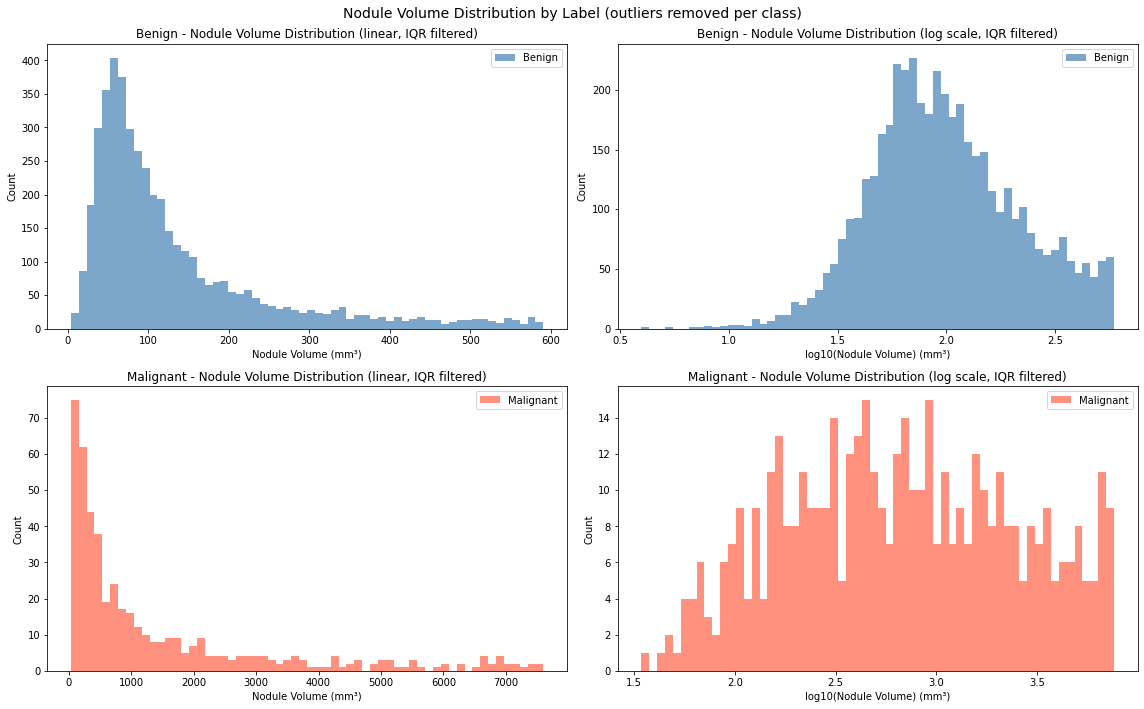

=== Benign Nodule Volume (mm³) ===


count    4563.000000
mean      133.894323
std       117.700563
min         3.959198
25%        58.021478
50%        91.648173
75%       161.377947
max       590.697518
Name: nodule_volume_mm3, dtype: float64

=== Malignant Nodule Volume (mm³) ===


count     470.000000
mean     1424.087374
std      1796.629621
min        34.396362
25%       239.169859
50%       646.271356
75%      1847.170851
max      7599.885768
Name: nodule_volume_mm3, dtype: float64

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_df = valid_volumes[["nodule_volume_mm3", "label"]].dropna()

def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series >= Q1 - 1.5 * IQR) & (series <= Q3 + 1.5 * IQR)

benign_df = plot_df[plot_df["label"] == 0].copy()
malignant_df = plot_df[plot_df["label"] == 1].copy()

benign_clean = benign_df[remove_outliers(benign_df["nodule_volume_mm3"])]
malignant_clean = malignant_df[remove_outliers(malignant_df["nodule_volume_mm3"])]

print(f"Benign: kept {len(benign_clean)}/{len(benign_df)} rows after outlier removal")
print(f"Malignant: kept {len(malignant_clean)}/{len(malignant_df)} rows after outlier removal")

label_names = {0: "Benign", 1: "Malignant"}
clean_dfs = {0: benign_clean, 1: malignant_clean}
colors = {0: "steelblue", 1: "tomato"}

for row_idx, (label, group) in enumerate(clean_dfs.items()):
    # Linear scale
    axes[row_idx, 0].hist(group["nodule_volume_mm3"], bins=60, alpha=0.7, color=colors[label], label=label_names[label])
    axes[row_idx, 0].set_xlabel("Nodule Volume (mm³)")
    axes[row_idx, 0].set_ylabel("Count")
    axes[row_idx, 0].set_title(f"{label_names[label]} - Nodule Volume Distribution (linear, IQR filtered)")
    axes[row_idx, 0].legend()

    # Log scale
    axes[row_idx, 1].hist(np.log10(group["nodule_volume_mm3"].clip(lower=1e-3)), bins=60, alpha=0.7, color=colors[label], label=label_names[label])
    axes[row_idx, 1].set_xlabel("log10(Nodule Volume) (mm³)")
    axes[row_idx, 1].set_ylabel("Count")
    axes[row_idx, 1].set_title(f"{label_names[label]} - Nodule Volume Distribution (log scale, IQR filtered)")
    axes[row_idx, 1].legend()

plt.suptitle("Nodule Volume Distribution by Label (outliers removed per class)", fontsize=14)
plt.tight_layout()
plt.show()

print("=== Benign Nodule Volume (mm³) ===")
display(benign_clean["nodule_volume_mm3"].describe())
print("=== Malignant Nodule Volume (mm³) ===")
display(malignant_clean["nodule_volume_mm3"].describe())


## Annotations centroid distance
The following code computes the distance from each matched nodule volume to the ground truth provided centroid.
The goal is to understand how much the MedSAM mask annotations differ from the ground truth annotated center of mass.

In [ ]:
from scipy import ndimage
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def compute_centroid_for_row(row):
    uid = row["uid"]
    instance_id = int(row["matched_instance_id"])
    img_path = base_dir / (uid + ".nii.gz")

    try:
        img = nib.load(str(img_path))
        affine = img.affine
        data = np.asanyarray(img.dataobj, dtype=np.uint8)

        # Get binary mask for this instance
        mask = (data == instance_id)

        if mask.sum() == 0:
            return {**row, "mask_centroid_x": np.nan, "mask_centroid_y": np.nan, "mask_centroid_z": np.nan, "mask_centroid_dist_mm": np.nan}

        # Compute voxel centroid
        cx, cy, cz = ndimage.center_of_mass(mask)

        # Convert voxel centroid to world coordinates using affine
        voxel_coords = np.array([cx, cy, cz, 1.0])
        world_coords = affine @ voxel_coords

        centroid_x, centroid_y, centroid_z = world_coords[:3]

        # Convert to LPS coordinates (ndimage assumes RAS)
        centroid_x_lps = - centroid_x
        centroid_y_lps = - centroid_y
        centroid_z_lps = centroid_z

        # Distance from annotation centroid (CoordX, CoordY, CoordZ)
        dist = np.linalg.norm([
            centroid_x_lps - row["CoordX"],
            centroid_y_lps - row["CoordY"],
            centroid_z_lps - row["CoordZ"]
        ])

        return {**row, "mask_centroid_x": centroid_x, "mask_centroid_y": centroid_y, "mask_centroid_z": centroid_z, "mask_centroid_dist_mm": dist}

    except Exception as e:
        print(f"Error processing {uid} instance {instance_id}: {e}")
        return {**row, "mask_centroid_x": np.nan, "mask_centroid_y": np.nan, "mask_centroid_z": np.nan, "mask_centroid_dist_mm": np.nan}





In [ ]:
rows_list = [row for _, row in valid_volumes.iterrows()]

with ThreadPoolExecutor(max_workers=16) as executor:
    results = list(tqdm(executor.map(compute_centroid_for_row, rows_list), total=len(rows_list)))

centroids_df = pd.DataFrame(results)


100%|██████████| 5917/5917 [22:33<00:00,  4.37it/s]  


Total lesions processed: 5917


KeyError: 'centroid_dist_mm'

In [ ]:

print(f"Total lesions processed: {len(centroids_df)}")
print(f"Lesions with valid centroid: {centroids_df['mask_centroid_dist_mm'].notna().sum()}")
print(f"Mean centroid distance (mm): {centroids_df['mask_centroid_dist_mm'].mean():.2f}")
display(centroids_df[["uid", "AnnotationID", "CoordX", "CoordY", "CoordZ", "mask_centroid_x", "mask_centroid_y", "mask_centroid_z", "mask_centroid_dist_mm"]].head(10))

centroids_df.to_csv("lesion_centroids_lps.csv", index=False)


Total lesions processed: 5917
Lesions with valid centroid: 5917
Mean centroid distance (mm): 1.07


,uid,AnnotationID,CoordX,CoordY,CoordZ,centroid_x,mask_centroid_y,mask_centroid_z,mask_centroid_dist_mm
0,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,218127_2_19990102,30.97,-118.97,383.08,-28.015641,120.191181,384.832769,3.645781
1,1.3.6.1.4.1.14519.5.2.1.7009.9004.305960261018...,218127_1_19990102,81.62,-169.17,329.02,-81.563920,169.059748,329.062500,0.130793
2,1.2.840.113654.2.55.26557501495886108029545380...,127001_2_20000102,81.28,166.06,-1005.30,-83.221781,-164.297270,-1006.873967,3.058611
3,1.2.840.113654.2.55.28651772260935079920691874...,130139_1_19990102,-95.36,-99.55,-85.46,95.408196,99.717696,-85.649026,0.257246
4,1.3.6.1.4.1.14519.5.2.1.7009.9004.134071451092...,205795_1_19990102,-93.41,137.00,-1350.56,93.388010,-136.993244,-1350.498696,0.065478
5,1.2.840.113654.2.55.56746211163529835673571630...,112395_1_20000102,-90.09,-70.07,1644.27,89.019442,69.493589,1655.521628,11.317133
6,1.3.6.1.4.1.14519.5.2.1.7009.9004.311426070231...,205372_1_20010102,-108.60,-172.91,-202.32,108.428694,172.986957,-202.177983,0.235450
7,1.2.840.113654.2.55.76667257327071516306942549...,126101_2_19990102,-56.60,-3.78,-127.90,56.453659,3.962451,-128.233202,0.407096
8,1.2.840.113654.2.55.76667257327071516306942549...,126101_1_19990102,113.72,-13.16,-53.89,-113.402327,13.416314,-53.898305,0.408266
9,1.2.840.113654.2.55.76667257327071516306942549...,126101_3_19990102,-22.07,-66.17,-71.11,21.667191,65.427083,-71.783333,1.080536


In [19]:
import pandas as pd 

centroids_df = pd.read_csv("lesion_centroids_lps.csv")


Benign: kept 5377/5377 rows after outlier removal
Malignant: kept 540/540 rows after outlier removal


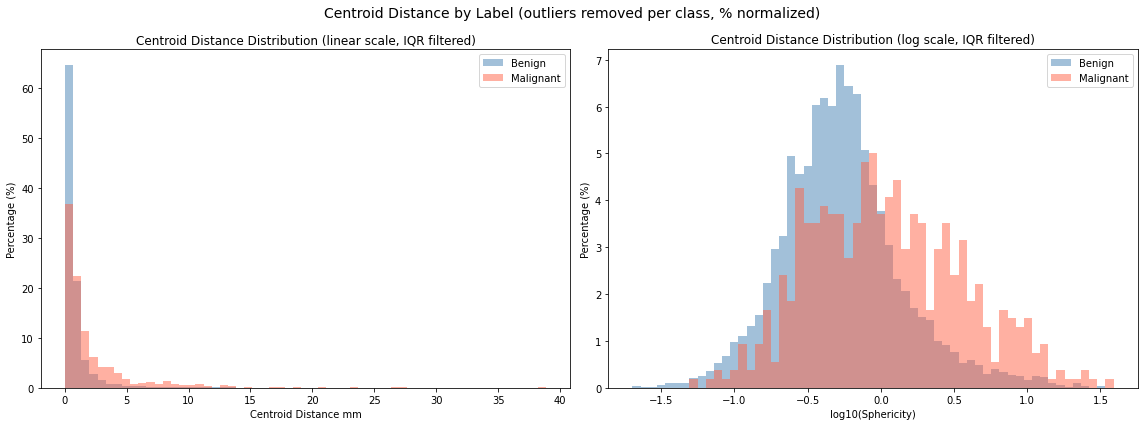

=== Benign Centroid Distance ===


count    5377.000000
mean        0.946906
std         1.794935
min         0.020078
25%         0.293483
50%         0.511776
75%         0.877299
max        32.885904
Name: mask_centroid_dist_mm, dtype: float64

=== Malignant Centroid Distance ===


count    540.000000
mean       2.300275
std        3.745670
min        0.052041
25%        0.433132
50%        0.997917
75%        2.534392
max       38.855878
Name: mask_centroid_dist_mm, dtype: float64

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = centroids_df[["mask_centroid_dist_mm", "label"]].dropna()

def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series >= Q1 - 1.5 * IQR) & (series <= Q3 + 1.5 * IQR)

benign_df = plot_df[plot_df["label"] == 0].copy()
malignant_df = plot_df[plot_df["label"] == 1].copy()

# benign_clean = benign_df[remove_outliers(benign_df["sphericity"])]
# malignant_clean = malignant_df[remove_outliers(malignant_df["sphericity"])]

benign_clean = benign_df
malignant_clean = malignant_df

print(f"Benign: kept {len(benign_clean)}/{len(benign_df)} rows after outlier removal")
print(f"Malignant: kept {len(malignant_clean)}/{len(malignant_df)} rows after outlier removal")

label_names = {0: "Benign", 1: "Malignant"}
clean_dfs = {0: benign_clean, 1: malignant_clean}
colors = {0: "steelblue", 1: "tomato"}

# Shared bins
all_vals = pd.concat([benign_clean["mask_centroid_dist_mm"], malignant_clean["mask_centroid_dist_mm"]])
linear_bins = np.linspace(all_vals.min(), all_vals.max(), 60)
log_bins = np.linspace(np.log10(all_vals.clip(lower=1e-3)).min(),
                       np.log10(all_vals.clip(lower=1e-3)).max(), 60)

for col_idx, (scale, bins) in enumerate(zip(["linear", "log"], [linear_bins, log_bins])):
    ax = axes[col_idx]
    for label, group in clean_dfs.items():
        data = group["mask_centroid_dist_mm"] if scale == "linear" else np.log10(group["mask_centroid_dist_mm"].clip(lower=1e-3))
        weights = np.ones(len(data)) / len(data) * 100
        ax.hist(data, bins=bins, alpha=0.5, color=colors[label], label=label_names[label], weights=weights)

    ax.set_xlabel("Centroid Distance mm" if scale == "linear" else "log10(Sphericity)")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Centroid Distance Distribution ({scale} scale, IQR filtered)")
    ax.legend()

plt.suptitle("Centroid Distance by Label (outliers removed per class, % normalized)", fontsize=14)
plt.tight_layout()
plt.show()

print("=== Benign Centroid Distance ===")
display(benign_clean["mask_centroid_dist_mm"].describe())
print("=== Malignant Centroid Distance ===")
display(malignant_clean["mask_centroid_dist_mm"].describe())

## Inspect nodule volume and distance
The following cells inspect the distribution of nodule volumes and distances.
The Pearson coefficient highlights a **weak negative correlation** between the two quantities.

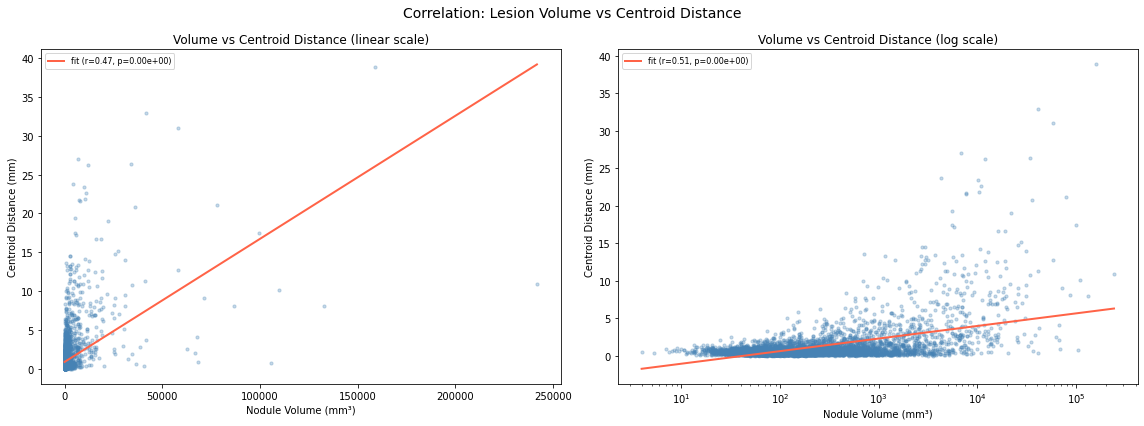

Correlation analysis (log volume vs centroid distance):

Pearson  r=0.5148, p=0.00e+00
Spearman r=0.3095, p=1.40e-131


In [22]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

volumes_df = pd.read_csv("lesion_volumes.csv")
centroids_df = pd.read_csv("lesion_centroids_lps.csv")

columns = ["AnnotationID", "mask_centroid_dist_mm"]

volumes_df = volumes_df.merge(
    centroids_df[columns],
    on="AnnotationID",
    how="left"
)

# Drop rows with missing values
plot_df = volumes_df[["nodule_volume_mm3", "mask_centroid_dist_mm"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, use_log in zip(axes, [False, True]):
    x = plot_df["nodule_volume_mm3"]
    y = plot_df["mask_centroid_dist_mm"]
    ax.scatter(x, y, alpha=0.3, s=10, color="steelblue")

    # Fit and plot regression line
    x_fit = np.log10(x) if use_log else x
    slope, intercept, r, p, _ = stats.linregress(x_fit, y)
    x_range = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_fit = slope * x_range + intercept
    x_plot = 10**x_range if use_log else x_range
    ax.plot(x_plot, y_fit, color="tomato", linewidth=2,
            label=f"fit (r={r:.2f}, p={p:.2e})")

    if use_log:
        ax.set_xscale("log")
        ax.set_title("Volume vs Centroid Distance (log scale)")
    else:
        ax.set_title("Volume vs Centroid Distance (linear scale)")

    ax.set_xlabel("Nodule Volume (mm³)")
    ax.set_ylabel("Centroid Distance (mm)")
    ax.legend(fontsize=8)

plt.suptitle("Correlation: Lesion Volume vs Centroid Distance", fontsize=14)
plt.tight_layout()
plt.show()

# Print Pearson and Spearman correlations
print("Correlation analysis (log volume vs centroid distance):\n")
pearson_r, pearson_p = stats.pearsonr(np.log10(plot_df["nodule_volume_mm3"]), plot_df["mask_centroid_dist_mm"])
spearman_r, spearman_p = stats.spearmanr(plot_df["nodule_volume_mm3"], plot_df["mask_centroid_dist_mm"])
print(f"Pearson  r={pearson_r:.4f}, p={pearson_p:.2e}")
print(f"Spearman r={spearman_r:.4f}, p={spearman_p:.2e}")


## Annotations sphericity
The following section computes the sphericity of each lesion. 

> The code is expected to run slow so it's strongly adviced to wrap it in an executable standalone script. The remaining pipeline can be run using the generated csv.

In [60]:
from skimage.measure import marching_cubes, mesh_surface_area
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def compute_sphericity_for_row(row):
    uid = row["uid"]
    instance_id = int(row["matched_instance_id"])
    img_path = base_dir / (uid + ".nii.gz")

    try:
        img = nib.load(str(img_path))
        zooms = img.header.get_zooms()[:3]
        voxel_volume = float(zooms[0] * zooms[1] * zooms[2])
        data = np.asanyarray(img.dataobj, dtype=np.uint8)

        mask = (data == instance_id)
        n_voxels = mask.sum()

        if n_voxels == 0:
            return {**row, "sphericity": np.nan, "surface_area_mm2": np.nan, "n_voxels": 0}

        # Physical volume
        volume = float(n_voxels) * voxel_volume

        # Surface mesh (spacing corrects for anisotropic voxels)
        verts, faces, _, _ = marching_cubes(mask.astype(np.float32), level=0.5, spacing=zooms)
        area = float(mesh_surface_area(verts, faces))

        if area == 0:
            return {**row, "sphericity": np.nan, "surface_area_mm2": 0.0, "n_voxels": int(n_voxels)}

        # Wadell's sphericity: ψ = π^(1/3) * (6V)^(2/3) / A
        sphericity = (np.pi ** (1 / 3) * (6 * volume) ** (2 / 3)) / area

        return {**row, "sphericity": sphericity, "surface_area_mm2": area, "n_voxels": int(n_voxels)}

    except Exception as e:
        print(f"Error processing {uid} instance {instance_id}: {e}")
        return {**row, "sphericity": np.nan, "surface_area_mm2": np.nan, "n_voxels": np.nan}

In [ ]:
rows_list = [row for _, row in valid_volumes[valid_volumes["matched_instance_id"].notna()].iterrows()]

with ThreadPoolExecutor(max_workers=16) as executor:
    results = list(tqdm(executor.map(compute_sphericity_for_row, rows_list), total=len(rows_list)))

sphericity_df = pd.DataFrame(results)

print(f"Total lesions processed: {len(sphericity_df)}")
print(f"Lesions with valid sphericity: {sphericity_df['sphericity'].notna().sum()}")
print(f"Mean sphericity: {sphericity_df['sphericity'].mean():.4f}")
print(f"Median sphericity: {sphericity_df['sphericity'].median():.4f}")
display(sphericity_df[["uid", "AnnotationID", "nodule_volume_mm3", "n_voxels", "surface_area_mm2", "sphericity"]].head(10))

sphericity_df.to_csv("lesion_sphericity.csv", index=False)

In [1]:
import pandas as pd

sphericity_df = pd.read_csv("lesion_sphericity_resampled.csv")

Benign: kept 5304/5304 rows after outlier removal
Malignant: kept 540/540 rows after outlier removal


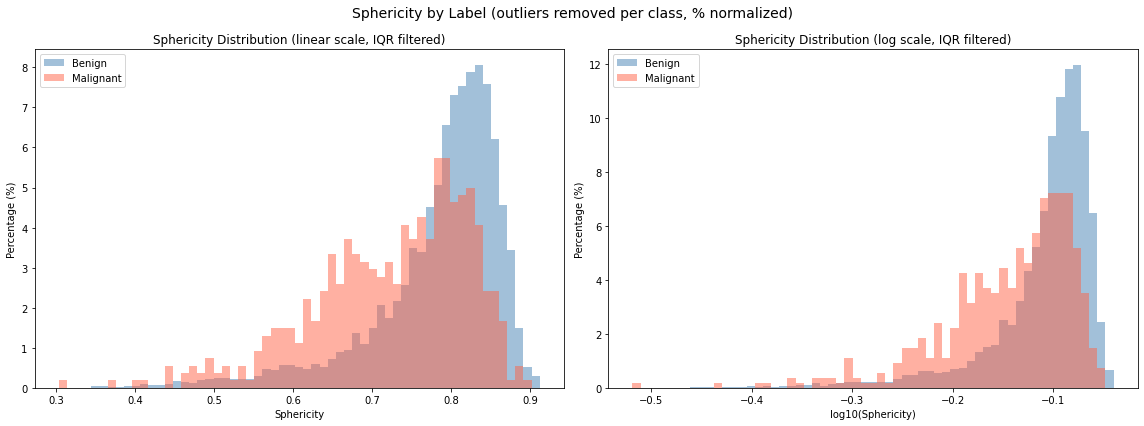

=== Benign Sphericity ===


count    5304.000000
mean        0.783592
std         0.083135
min         0.348245
25%         0.755259
50%         0.805254
75%         0.838231
max         0.911738
Name: sphericity, dtype: float64

=== Malignant Sphericity ===


count    540.000000
mean       0.724167
std        0.098643
min        0.302843
25%        0.663391
50%        0.742674
75%        0.801159
max        0.893905
Name: sphericity, dtype: float64

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = sphericity_df[["sphericity", "label"]].dropna()

def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series >= Q1 - 1.5 * IQR) & (series <= Q3 + 1.5 * IQR)

benign_df = plot_df[plot_df["label"] == 0].copy()
malignant_df = plot_df[plot_df["label"] == 1].copy()

# benign_clean = benign_df[remove_outliers(benign_df["sphericity"])]
# malignant_clean = malignant_df[remove_outliers(malignant_df["sphericity"])]

benign_clean = benign_df
malignant_clean = malignant_df

print(f"Benign: kept {len(benign_clean)}/{len(benign_df)} rows after outlier removal")
print(f"Malignant: kept {len(malignant_clean)}/{len(malignant_df)} rows after outlier removal")

label_names = {0: "Benign", 1: "Malignant"}
clean_dfs = {0: benign_clean, 1: malignant_clean}
colors = {0: "steelblue", 1: "tomato"}

# Shared bins
all_vals = pd.concat([benign_clean["sphericity"], malignant_clean["sphericity"]])
linear_bins = np.linspace(all_vals.min(), all_vals.max(), 60)
log_bins = np.linspace(np.log10(all_vals.clip(lower=1e-3)).min(),
                       np.log10(all_vals.clip(lower=1e-3)).max(), 60)

for col_idx, (scale, bins) in enumerate(zip(["linear", "log"], [linear_bins, log_bins])):
    ax = axes[col_idx]
    for label, group in clean_dfs.items():
        data = group["sphericity"] if scale == "linear" else np.log10(group["sphericity"].clip(lower=1e-3))
        weights = np.ones(len(data)) / len(data) * 100
        ax.hist(data, bins=bins, alpha=0.5, color=colors[label], label=label_names[label], weights=weights)

    ax.set_xlabel("Sphericity" if scale == "linear" else "log10(Sphericity)")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Sphericity Distribution ({scale} scale, IQR filtered)")
    ax.legend()

plt.suptitle("Sphericity by Label (outliers removed per class, % normalized)", fontsize=14)
plt.tight_layout()
plt.show()

print("=== Benign Sphericity ===")
display(benign_clean["sphericity"].describe())
print("=== Malignant Sphericity ===")
display(malignant_clean["sphericity"].describe())

### Sphericity vs Nodule Volume
Display a scatter plot of nodules sphericity and volumes in order to analyze their correlation

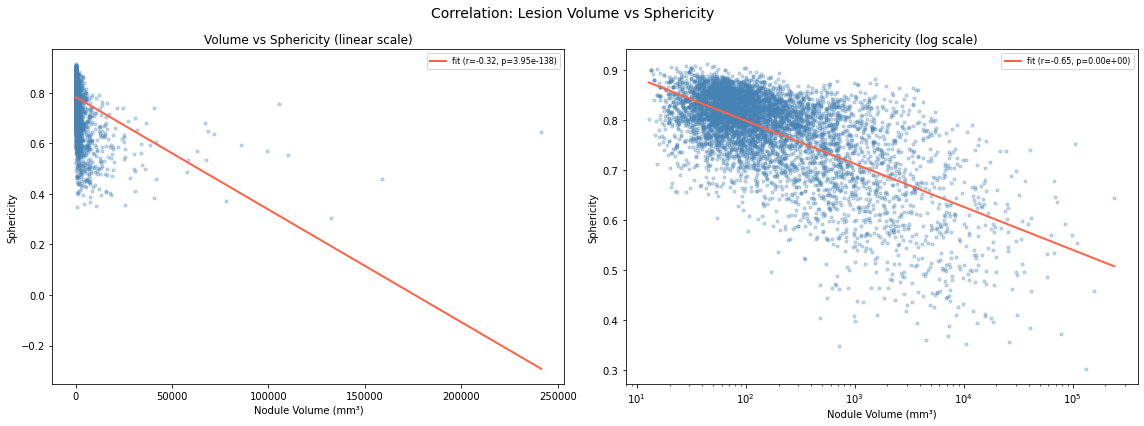

Correlation analysis (log volume vs sphericity):

Pearson  r=-0.6501, p=0.00e+00
Spearman r=-0.5329, p=0.00e+00


In [8]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

var = "mesh_volume_mm3"
plot_df = sphericity_df[[f"{var}", "sphericity"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, use_log in zip(axes, [False, True]):
    x = plot_df[f"{var}"]
    y = plot_df["sphericity"]

    ax.scatter(x, y, alpha=0.3, s=10, color="steelblue")

    x_fit = np.log10(x) if use_log else x
    slope, intercept, r, p, _ = stats.linregress(x_fit, y)
    x_range = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_fit = slope * x_range + intercept
    x_plot = 10**x_range if use_log else x_range
    ax.plot(x_plot, y_fit, color="tomato", linewidth=2,
            label=f"fit (r={r:.2f}, p={p:.2e})")

    if use_log:
        ax.set_xscale("log")
        ax.set_title("Volume vs Sphericity (log scale)")
    else:
        ax.set_title("Volume vs Sphericity (linear scale)")

    ax.set_xlabel("Nodule Volume (mm³)")
    ax.set_ylabel("Sphericity")
    ax.legend(fontsize=8)

plt.suptitle("Correlation: Lesion Volume vs Sphericity", fontsize=14)
plt.tight_layout()
plt.show()

pearson_r, pearson_p = stats.pearsonr(np.log10(plot_df[f"{var}"]), plot_df["sphericity"])
spearman_r, spearman_p = stats.spearmanr(plot_df[f"{var}"], plot_df["sphericity"])
print("Correlation analysis (log volume vs sphericity):\n")
print(f"Pearson  r={pearson_r:.4f}, p={pearson_p:.2e}")
print(f"Spearman r={spearman_r:.4f}, p={spearman_p:.2e}")

### Sphericity vs Centroid distace
Display a scatter plot of nodules sphericity and centroid distance in order to analyze their correlation

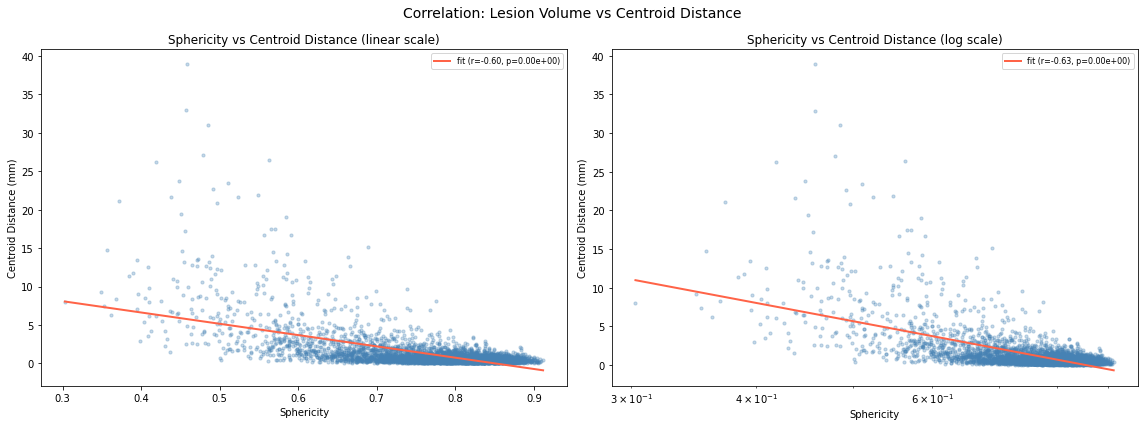

Correlation analysis (log sphericity vs centroid distance):

Pearson  r=-0.6341, p=0.00e+00
Spearman r=-0.4355, p=4.24e-269


In [25]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

sphericity_df = pd.read_csv("lesion_sphericity_resampled.csv")
centroids_df = pd.read_csv("lesion_centroids_lps.csv")

columns = ["AnnotationID", "mask_centroid_dist_mm"]

sphericity_df = sphericity_df.merge(
    centroids_df[columns],
    on="AnnotationID",
    how="left"
)

# Drop rows with missing values
plot_df = sphericity_df[["sphericity", "mask_centroid_dist_mm"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, use_log in zip(axes, [False, True]):
    x = plot_df["sphericity"]
    y = plot_df["mask_centroid_dist_mm"]
    ax.scatter(x, y, alpha=0.3, s=10, color="steelblue")

    # Fit and plot regression line
    x_fit = np.log10(x) if use_log else x
    slope, intercept, r, p, _ = stats.linregress(x_fit, y)
    x_range = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_fit = slope * x_range + intercept
    x_plot = 10**x_range if use_log else x_range
    ax.plot(x_plot, y_fit, color="tomato", linewidth=2,
            label=f"fit (r={r:.2f}, p={p:.2e})")

    if use_log:
        ax.set_xscale("log")
        ax.set_title("Sphericity vs Centroid Distance (log scale)")
    else:
        ax.set_title("Sphericity vs Centroid Distance (linear scale)")

    ax.set_xlabel("Sphericity")
    ax.set_ylabel("Centroid Distance (mm)")
    ax.legend(fontsize=8)

plt.suptitle("Correlation: Lesion Volume vs Centroid Distance", fontsize=14)
plt.tight_layout()
plt.show()

# Print Pearson and Spearman correlations
print("Correlation analysis (log sphericity vs centroid distance):\n")
pearson_r, pearson_p = stats.pearsonr(np.log10(plot_df["sphericity"]), plot_df["mask_centroid_dist_mm"])
spearman_r, spearman_p = stats.spearmanr(plot_df["sphericity"], plot_df["mask_centroid_dist_mm"])
print(f"Pearson  r={pearson_r:.4f}, p={pearson_p:.2e}")
print(f"Spearman r={spearman_r:.4f}, p={spearman_p:.2e}")


## Annotations diameters
The following section assumes `lesion_nlst_diameter.csv` to be present. (run the dedicated script to generate it at  `scripts/compute_nlst_diameter.py`).
The diameter has been computed following the NLST convetion and serves as the most meaningful insight for comparing the dataset with other ones in this domain. (LUNA16)

**LUNA25 Declared (NLST)**:
- Benign: 7.38 ± 4.49 mm (5.80 mm)
- Malignant: 14.42 ± 9.31 (11.90 mm)

### Inspect LUNA25 diameters

In [3]:
import pandas as pd

diameters_df = pd.read_csv("lesion_nlst_diameters.csv")


Benign: kept 5377/5377 rows after outlier removal
Malignant: kept 540/540 rows after outlier removal


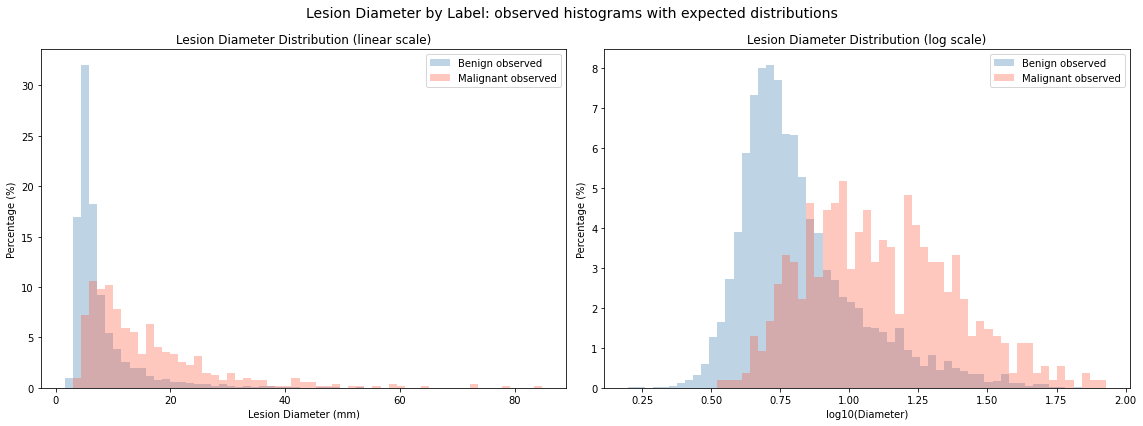

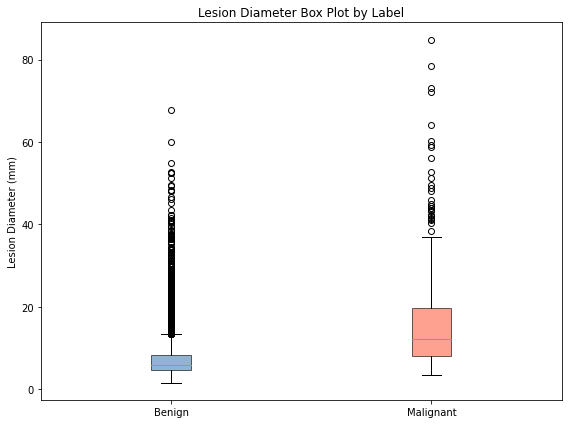

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = diameters_df[["nlst_diameter_mm", "label"]].dropna()

def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series >= Q1 - 1.5 * IQR) & (series <= Q3 + 1.5 * IQR)

benign_df = plot_df[plot_df["label"] == 0].copy()
malignant_df = plot_df[plot_df["label"] == 1].copy()

# benign_clean = benign_df[remove_outliers(benign_df["nlst_diameter_mm"])]
# malignant_clean = malignant_df[remove_outliers(malignant_df["nlst_diameter_mm"])]

benign_clean = benign_df
malignant_clean = malignant_df

print(f"Benign: kept {len(benign_clean)}/{len(benign_df)} rows after outlier removal")
print(f"Malignant: kept {len(malignant_clean)}/{len(malignant_df)} rows after outlier removal")

label_names = {0: "Benign", 1: "Malignant"}
clean_dfs = {0: benign_clean, 1: malignant_clean}
colors = {0: "steelblue", 1: "tomato"}

# Expected NLST diameter stats from the markdown above
expected_stats = {
    0: {"mean": 7.38, "std": 4.49, "median": 5.80},
    1: {"mean": 14.42, "std": 9.31, "median": 11.90},
}

# Shared bins
all_vals = pd.concat([benign_clean["nlst_diameter_mm"], malignant_clean["nlst_diameter_mm"]])
linear_bins = np.linspace(all_vals.min(), all_vals.max(), 60)
log_bins = np.linspace(
    np.log10(all_vals.clip(lower=1e-3)).min(),
    np.log10(all_vals.clip(lower=1e-3)).max(),
    60
)

linear_bin_width = linear_bins[1] - linear_bins[0]
log_bin_width = log_bins[1] - log_bins[0]

for col_idx, (scale, bins) in enumerate(zip(["linear", "log"], [linear_bins, log_bins])):
    ax = axes[col_idx]

    for label, group in clean_dfs.items():
        if len(group) == 0:
            continue

        raw_data = group["nlst_diameter_mm"]
        hist_data = raw_data if scale == "linear" else np.log10(raw_data.clip(lower=1e-3))
        weights = np.ones(len(hist_data)) / len(hist_data) * 100

        ax.hist(
            hist_data,
            bins=bins,
            alpha=0.35,
            color=colors[label],
            label=f"{label_names[label]} observed",
            weights=weights,
        )


    ax.set_xlabel("Lesion Diameter (mm)" if scale == "linear" else "log10(Diameter)")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Lesion Diameter Distribution ({scale} scale)")
    ax.legend()

plt.suptitle("Lesion Diameter by Label: observed histograms with expected distributions", fontsize=14)
plt.tight_layout()
plt.show()



# Box plots
fig2, ax2 = plt.subplots(figsize=(8, 6))
data_to_plot = [benign_clean["nlst_diameter_mm"].dropna().values, malignant_clean["nlst_diameter_mm"].dropna().values]
bp = ax2.boxplot(data_to_plot, patch_artist=True, labels=["Benign", "Malignant"])
for patch, color in zip(bp["boxes"], [colors[0], colors[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_ylabel("Lesion Diameter (mm)")
ax2.set_title("Lesion Diameter Box Plot by Label")
plt.tight_layout()
plt.show()

In [ ]:

print("=== Benign Lesion Diameter ===")
display(benign_clean["nlst_diameter_mm"].describe())
print("Expected benign stats:", expected_stats[0])

print("=== Malignant Lesion Diameter ===")
display(malignant_clean["nlst_diameter_mm"].describe())
print("Expected malignant stats:", expected_stats[1])


print("=== Overall Lesion Diameter ===")
display(plot_df["nlst_diameter_mm"].describe())

=== Benign Lesion Diameter ===


count    5377.000000
mean        7.702415
std         5.711948
min         1.586351
25%         4.711058
50%         5.832207
75%         8.195885
max        67.738123
Name: nlst_diameter_mm, dtype: float64

Expected benign stats: {'mean': 7.38, 'std': 4.49, 'median': 5.8}
=== Malignant Lesion Diameter ===


count    540.000000
mean      15.877288
std       11.559068
min        3.542123
25%        8.129778
50%       12.241248
75%       19.686174
max       84.862885
Name: nlst_diameter_mm, dtype: float64

Expected malignant stats: {'mean': 14.42, 'std': 9.31, 'median': 11.9}
=== Overall Lesion Diameter ===


count    5917.000000
mean        8.448474
std         6.882209
min         1.586351
25%         4.799523
50%         6.093755
75%         9.094434
max        84.862885
Name: nlst_diameter_mm, dtype: float64

In [11]:
from scipy import stats

plot_df = diameters_df[["nlst_diameter_mm", "label"]].dropna()

label_names = {0: "Benign", 1: "Malignant", 2: "Overall"}

for label in [0, 1, 2]:
    if label == 2:
        group = plot_df["nlst_diameter_mm"].values
    else:
        group = plot_df[plot_df["label"] == label]["nlst_diameter_mm"].values
        
    skewness = stats.skew(group)
    kurt = stats.kurtosis(group)  # excess kurtosis (Fisher's definition)
    mean = group.mean()
    std = group.std()
    median = np.median(group)

    print(f"\n[{label_names[label]}]")
    print(f"  N         : {len(group)}")
    print(f"  Mean      : {mean:.4f} mm")
    print(f"  Std       : {std:.4f} mm")
    print(f"  Median    : {median:.4f} mm")
    print(f"  Skewness  : {skewness:.4f}  ({'right-skewed' if skewness > 0 else 'left-skewed'})")
    print(f"  Kurtosis  : {kurt:.4f}  ({'leptokurtic' if kurt > 0 else 'platykurtic'})")

    # Normality tests
    stat_sw, p_sw = stats.shapiro(group[:5000])  # Shapiro-Wilk limited to 5000 samples
    stat_ks, p_ks = stats.kstest(group, "norm", args=(mean, std))

    print(f"  Shapiro-Wilk  : stat={stat_sw:.4f}, p={p_sw:.4e} -> {'NOT normal' if p_sw < 0.05 else 'normal'}")
    print(f"  KS vs Normal  : stat={stat_ks:.4f}, p={p_ks:.4e} -> {'NOT normal' if p_ks < 0.05 else 'normal'}")


[Benign]
  N         : 5377
  Mean      : 7.7024 mm
  Std       : 5.7114 mm
  Median    : 5.8322 mm
  Skewness  : 3.5225  (right-skewed)
  Kurtosis  : 17.2827  (leptokurtic)
  Shapiro-Wilk  : stat=0.6401, p=0.0000e+00 -> NOT normal
  KS vs Normal  : stat=0.2195, p=7.0050e-228 -> NOT normal

[Malignant]
  N         : 540
  Mean      : 15.8773 mm
  Std       : 11.5484 mm
  Median    : 12.2412 mm
  Skewness  : 2.2575  (right-skewed)
  Kurtosis  : 7.0426  (leptokurtic)
  Shapiro-Wilk  : stat=0.7876, p=6.2655e-26 -> NOT normal
  KS vs Normal  : stat=0.1527, p=1.8705e-11 -> NOT normal

[Overall]
  N         : 5917
  Mean      : 8.4485 mm
  Std       : 6.8816 mm
  Median    : 6.0938 mm
  Skewness  : 3.5460  (right-skewed)
  Kurtosis  : 18.3899  (leptokurtic)
  Shapiro-Wilk  : stat=0.6431, p=0.0000e+00 -> NOT normal
  KS vs Normal  : stat=0.2207, p=1.5226e-253 -> NOT normal


#### Fit to distribution
Find the distribution that best fits the data


[Benign] N=5377
  Gaussian      : mu=7.702, std=5.711, BIC=34014.94, Wasserstein=2.6299
  Skew-normal   : a=17.729, loc=3.058, scale=7.362, BIC=29652.08, Wasserstein=1.9159
  GMM K=1        : BIC=34014.94
  GMM K=2        : BIC=27727.77
  GMM K=3        : BIC=26926.47
  GMM K=4        : BIC=26857.39
  >> Best GMM   : K=4, BIC=26857.39, Wasserstein=0.1996


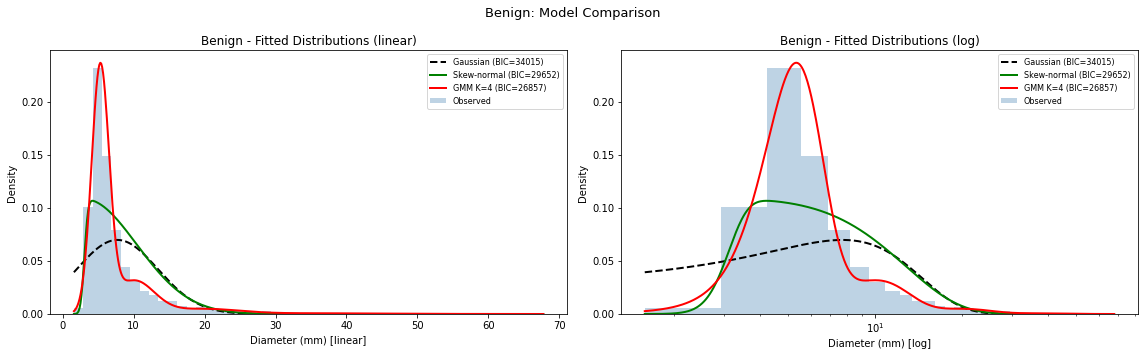


[Malignant] N=540
  Gaussian      : mu=15.877, std=11.548, BIC=4187.30, Wasserstein=3.7287
  Skew-normal   : a=36.120, loc=4.218, scale=16.410, BIC=3843.72, Wasserstein=2.2573
  GMM K=1        : BIC=4187.30
  GMM K=2        : BIC=3916.25
  GMM K=3        : BIC=3819.65
  GMM K=4        : BIC=3828.31
  >> Best GMM   : K=3, BIC=3819.65, Wasserstein=0.7378


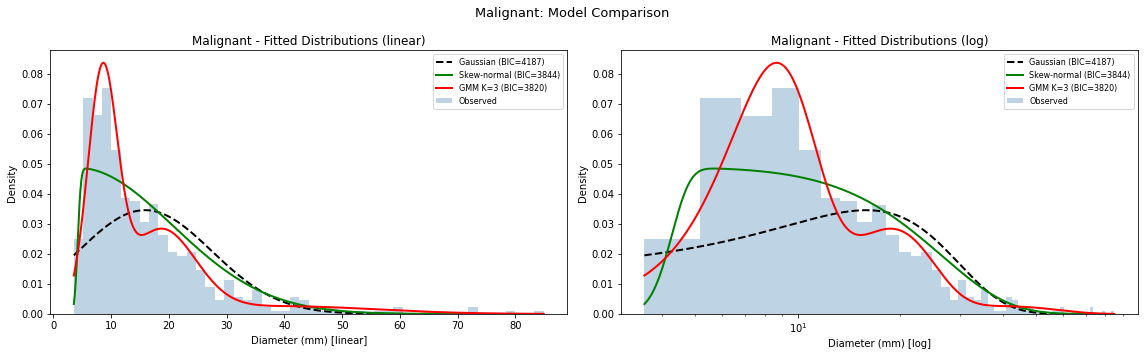

,gaussian_bic,skewnorm_bic,gmm_best_k,gmm_best_bic,gaussian_W,skewnorm_W,gmm_W
name,,,,,,,
Benign,34014.936101,29652.078979,4,26857.387647,2.629938,1.915898,0.199601
Malignant,4187.303681,3843.719202,3,3819.649738,3.728747,2.257309,0.737808


In [9]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import skewnorm
from scipy.optimize import minimize
from sklearn.mixture import GaussianMixture
from scipy.stats import wasserstein_distance

import matplotlib.pyplot as plt

label_names = {0: "Benign", 1: "Malignant"}
expected_stats = {
    0: {"mean": 7.38, "std": 4.49},
    1: {"mean": 14.42, "std": 9.31},
}

plot_df = diameters_df[["nlst_diameter_mm", "label"]].dropna()

results = []

for label in [0, 1]:
    data = plot_df[plot_df["label"] == label]["nlst_diameter_mm"].values
    name = label_names[label]
    n = len(data)
    data_col = data.reshape(-1, 1)

    print(f"\n{'='*60}")
    print(f"[{name}] N={n}")
    print(f"{'='*60}")

    # ── 1. Gaussian (baseline) ──────────────────────────────────
    mu_g, std_g = stats.norm.fit(data)
    log_lik_g = np.sum(stats.norm.logpdf(data, mu_g, std_g))
    k_g = 2
    bic_g = k_g * np.log(n) - 2 * log_lik_g
    samples_g = np.random.default_rng(42).normal(mu_g, std_g, n)
    w_g = wasserstein_distance(data, samples_g)
    print(f"  Gaussian      : mu={mu_g:.3f}, std={std_g:.3f}, BIC={bic_g:.2f}, Wasserstein={w_g:.4f}")

    # ── 2. Skew-normal ──────────────────────────────────────────
    a_sn, loc_sn, scale_sn = skewnorm.fit(data)
    log_lik_sn = np.sum(skewnorm.logpdf(data, a_sn, loc_sn, scale_sn))
    k_sn = 3
    bic_sn = k_sn * np.log(n) - 2 * log_lik_sn
    samples_sn = skewnorm.rvs(a_sn, loc_sn, scale_sn, size=n, random_state=42)
    w_sn = wasserstein_distance(data, samples_sn)
    print(f"  Skew-normal   : a={a_sn:.3f}, loc={loc_sn:.3f}, scale={scale_sn:.3f}, BIC={bic_sn:.2f}, Wasserstein={w_sn:.4f}")

    # ── 3. GMM (K=1..4, pick best BIC) ─────────────────────────
    gmm_results = []
    for k in range(1, 5):
        gmm = GaussianMixture(n_components=k, random_state=42, max_iter=500)
        gmm.fit(data_col)
        bic_k = gmm.bic(data_col)
        gmm_results.append((k, gmm, bic_k))
        print(f"  GMM K={k}        : BIC={bic_k:.2f}")

    best_k, best_gmm, best_bic_gmm = min(gmm_results, key=lambda x: x[2])
    samples_gmm, _ = best_gmm.sample(n)
    samples_gmm = samples_gmm.ravel()
    w_gmm = wasserstein_distance(data, samples_gmm)
    print(f"  >> Best GMM   : K={best_k}, BIC={best_bic_gmm:.2f}, Wasserstein={w_gmm:.4f}")

    results.append({
        "label": label,
        "name": name,
        "gaussian_bic": bic_g,
        "skewnorm_bic": bic_sn,
        "gmm_best_k": best_k,
        "gmm_best_bic": best_bic_gmm,
        "gaussian_W": w_g,
        "skewnorm_W": w_sn,
        "gmm_W": w_gmm,
    })

    # ── 5. Plot ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    x_plot = np.linspace(data.min(), data.max(), 500)

    for ax, use_log in zip(axes, [False, True]):
        if use_log:
            ax.set_xscale("log")
            x_plot_ax = np.exp(np.linspace(np.log(max(data.min(), 1e-3)), np.log(data.max()), 500))
        else:
            x_plot_ax = x_plot

        # Histogram
        ax.hist(data, bins=50, density=True, alpha=0.35, color="steelblue", label="Observed")

        # Gaussian
        ax.plot(x_plot_ax, stats.norm.pdf(x_plot_ax, mu_g, std_g),
                "k--", lw=2, label=f"Gaussian (BIC={bic_g:.0f})")

        # Skew-normal
        ax.plot(x_plot_ax, skewnorm.pdf(x_plot_ax, a_sn, loc_sn, scale_sn),
                "g-", lw=2, label=f"Skew-normal (BIC={bic_sn:.0f})")

        # Best GMM
        gmm_pdf = np.exp(best_gmm.score_samples(x_plot_ax.reshape(-1, 1)))
        ax.plot(x_plot_ax, gmm_pdf,
                "r-", lw=2, label=f"GMM K={best_k} (BIC={best_bic_gmm:.0f})")

        scale = "log" if use_log else "linear"
        ax.set_xlabel(f"Diameter (mm) [{scale}]")
        ax.set_ylabel("Density")
        ax.set_title(f"{name} - Fitted Distributions ({scale})")
        ax.legend(fontsize=8)

    plt.suptitle(f"{name}: Model Comparison", fontsize=13)
    plt.tight_layout()
    plt.show()

# ── Summary table ────────────────────────────────────────────────
summary_df = pd.DataFrame(results).set_index("name")
display(summary_df[[
    "gaussian_bic", "skewnorm_bic", "gmm_best_k", "gmm_best_bic",
    "gaussian_W", "skewnorm_W", "gmm_W"
]])

### Diameter growth
The following section checks the average growth for lesions that have been tracked at multiple followups

In [7]:
import pandas as pd

diameters = pd.read_csv("lesion_nlst_diameters.csv")
# groups with >1 row are tracked lesions
tracked = diameters.groupby("NoduleID").filter(lambda g: len(g) > 1).copy()


In [8]:

# check whether label changes within each tracked lesion
label_change = (
    tracked.groupby("NoduleID")["label"]
    .nunique()
    .reset_index(name="n_unique_labels")
)
label_change["label_changed"] = label_change["n_unique_labels"] > 1

print(f"Total tracked lesions (NoduleID with >1 row): {label_change.shape[0]}")
print(f"Tracked lesions with label change: {label_change['label_changed'].sum()}")




Total tracked lesions (NoduleID with >1 row): 1546
Tracked lesions with label change: 0


In [11]:
# Compute average diameter growth per tracked lesion (NoduleID), sorting by date ascending
tracked_growth_src = tracked.copy()  # uses the already available "tracked" DataFrame

# Parse StudyDate for robust chronological sorting (expects YYYYMMDD)
tracked_growth_src["StudyDate_dt"] = pd.to_datetime(
    tracked_growth_src["StudyDate"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

def summarize_growth(g):
    g = g.sort_values(["StudyDate_dt", "AnnotationID"]).copy()

    d = g["nlst_diameter_mm"].astype(float)
    deltas = d.diff().dropna()

    first_d = d.iloc[0]
    last_d = d.iloc[-1]
    n_tp = len(g)

    return pd.Series({
        "label": g["label"].iloc[0],
        "n_timepoints": n_tp,
        "first_study_date": g["StudyDate"].iloc[0],
        "last_study_date": g["StudyDate"].iloc[-1],
        "first_diameter_mm": first_d,
        "last_diameter_mm": last_d,
        "net_growth_mm": last_d - first_d,
        "avg_growth_mm_per_step": deltas.mean() if len(deltas) else 0.0,   # mean of consecutive changes
        "avg_growth_mm_net_per_step": (last_d - first_d) / (n_tp - 1) if n_tp > 1 else 0.0,
    })

lesion_growth = (
    tracked_growth_src
    .groupby("NoduleID", as_index=False)
    .apply(summarize_growth)
    .reset_index(drop=True)
)

print(f"Tracked lesions summarized: {len(lesion_growth)}")
display(lesion_growth.head(20))



Tracked lesions summarized: 1546


,NoduleID,label,n_timepoints,first_study_date,last_study_date,first_diameter_mm,last_diameter_mm,net_growth_mm,avg_growth_mm_per_step,avg_growth_mm_net_per_step
0,100012_1,1.0,2.0,19990102.0,20000102.0,10.073860,21.259922,11.186062,11.186062,11.186062
1,100035_1,0.0,3.0,19990102.0,20010102.0,3.670785,3.819498,0.148713,0.074357,0.074357
2,100069_1,0.0,2.0,20000102.0,20010102.0,6.522297,4.970151,-1.552145,-1.552145,-1.552145
3,100069_2,0.0,2.0,20000102.0,20010102.0,7.716366,6.972165,-0.744201,-0.744201,-0.744201
4,100069_3,0.0,2.0,20000102.0,20010102.0,6.648360,5.376212,-1.272148,-1.272148,-1.272148
5,100095_1,0.0,3.0,19990102.0,20010102.0,4.115102,5.272171,1.157069,0.578535,0.578535
6,100095_2,0.0,3.0,19990102.0,20010102.0,8.440196,8.336785,-0.103411,-0.051705,-0.051705
7,100095_3,0.0,3.0,19990102.0,20010102.0,7.008176,7.721996,0.713820,0.356910,0.356910
8,100095_5,0.0,3.0,19990102.0,20010102.0,7.249789,7.479650,0.229861,0.114930,0.114930
9,100150_1,0.0,2.0,20000102.0,20010102.0,5.084351,5.302925,0.218574,0.218574,0.218574


In [14]:
malignant_tracked = lesion_growth[lesion_growth["label"] == 1.0]
benign_tracked = lesion_growth[lesion_growth["label"] != 1.0]

# Optional: overall average growth across tracked lesions
print("Overall Malignant mean avg_growth_mm_per_step:", malignant_tracked["avg_growth_mm_per_step"].mean())
print("Overall Benign mean avg_growth_mm_per_step:", benign_tracked["avg_growth_mm_per_step"].mean())

Overall Malignant mean avg_growth_mm_per_step: 5.263124088605347
Overall Benign mean avg_growth_mm_per_step: 0.002835979969638594


### LUNA16 annotations
Inspect LUNA16 diameters and compare with LUNA25 (MedSAM2 derived ones).


While LUNA16 and LUNA25 exhibit **similar central tendencies** (mean and median diameters), **LUNA25 shows substantially increased variance driven by extreme values**. This is reflected in significantly **higher skewness** (3.55 vs 1.75) and **kurtosis** (18.4 vs 2.83), as well as a **much larger maximum diameter** (84.9 mm vs 32.3 mm).

The interquartile ranges are comparable, indicating that the primary differences arise in the upper tail rather than the bulk of the distribution.


> LUNA25 introduces substantial scale heterogeneity and heavy-tailed size distribution, which breaks the implicit assumptions of the detection model regarding object size priors and feature scale consistency. This results in degraded performance due to anchor mismatch, regression instability, and increased intra-class variability, potentially compounded by segmentation-induced label noise.

In [1]:
import pandas as pd

diameters_16 = pd.read_csv("luna16-annotations.csv")
diameters_25 = pd.read_csv("lesion_nlst_diameters.csv")

In [3]:
from scipy import stats
import numpy as np

plot_df = diameters_16[["diameter_mm"]].dropna()

group = plot_df["diameter_mm"].values
skewness = stats.skew(group)
kurt = stats.kurtosis(group)  # excess kurtosis (Fisher's definition)
mean = group.mean()
std = group.std()
median = np.median(group)

print(f"  N         : {len(group)}")
print(f"  Mean      : {mean:.4f} mm")
print(f"  Std       : {std:.4f} mm")
print(f"  Median    : {median:.4f} mm")
print(f"  Skewness  : {skewness:.4f}  ({'right-skewed' if skewness > 0 else 'left-skewed'})")
print(f"  Kurtosis  : {kurt:.4f}  ({'leptokurtic' if kurt > 0 else 'platykurtic'})")

# Normality tests
stat_sw, p_sw = stats.shapiro(group[:5000])  # Shapiro-Wilk limited to 5000 samples
stat_ks, p_ks = stats.kstest(group, "norm", args=(mean, std))

print(f"  Shapiro-Wilk  : stat={stat_sw:.4f}, p={p_sw:.4e} -> {'NOT normal' if p_sw < 0.05 else 'normal'}")
print(f"  KS vs Normal  : stat={stat_ks:.4f}, p={p_ks:.4e} -> {'NOT normal' if p_ks < 0.05 else 'normal'}")

print("\n \n=== LUNA16 Lesion Diameter ===")
print(plot_df["diameter_mm"].describe())

  N         : 1186
  Mean      : 8.3065 mm
  Std       : 4.7600 mm
  Median    : 6.4336 mm
  Skewness  : 1.7458  (right-skewed)
  Kurtosis  : 2.8303  (leptokurtic)
  Shapiro-Wilk  : stat=0.7949, p=3.2008e-36 -> NOT normal
  KS vs Normal  : stat=0.1859, p=2.3731e-36 -> NOT normal

 
=== LUNA16 Lesion Diameter ===
count    1186.000000
mean        8.306527
std         4.762033
min         3.253443
25%         5.107177
50%         6.433600
75%         9.696301
max        32.270030
Name: diameter_mm, dtype: float64


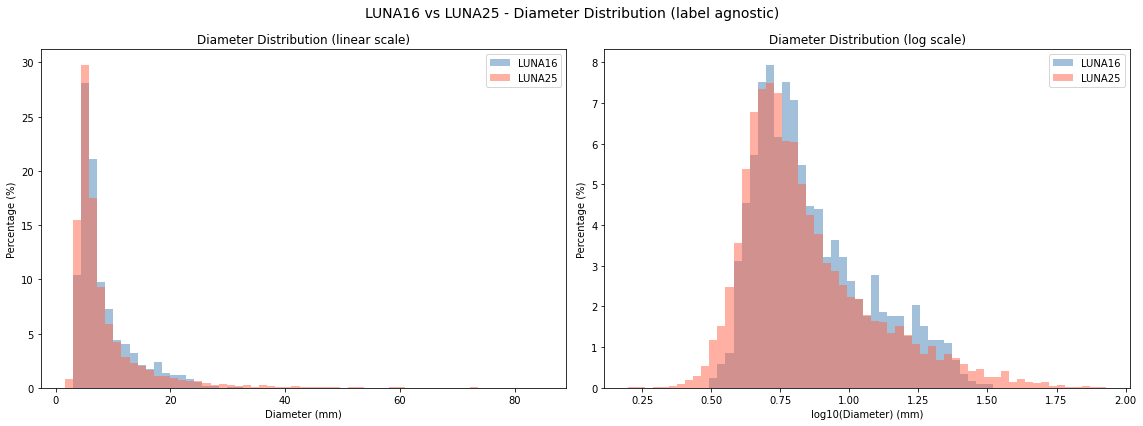

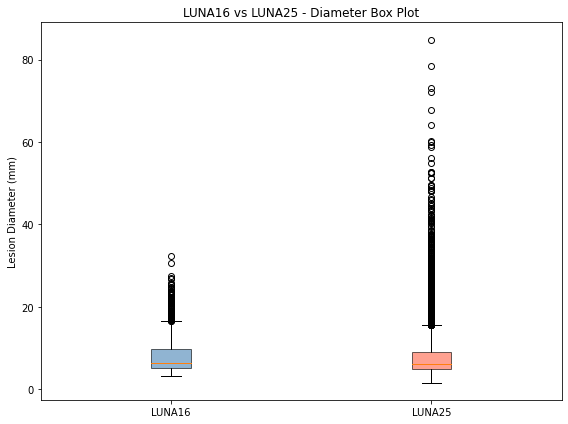


=== LUNA16 (N=1186) ===
  Mean   : 8.3065 mm
  Std    : 4.7600 mm
  Median : 6.4336 mm

=== LUNA25 (N=5917) ===
  Mean   : 8.4485 mm
  Std    : 6.8816 mm
  Median : 6.0938 mm

KS test (LUNA16 vs LUNA25): stat=0.0794, p=7.1623e-06 -> significantly different


In [4]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

luna16_diams = diameters_16["diameter_mm"].dropna().values
luna25_diams = diameters_25["nlst_diameter_mm"].dropna().values

all_vals = np.concatenate([luna16_diams, luna25_diams])
linear_bins = np.linspace(all_vals.min(), all_vals.max(), 60)
log_bins = np.linspace(np.log10(np.clip(all_vals, 1e-3, None)).min(),
                       np.log10(np.clip(all_vals, 1e-3, None)).max(), 60)

datasets = {
    "LUNA16": (luna16_diams, "steelblue"),
    "LUNA25": (luna25_diams, "tomato"),
}

for col_idx, (scale, bins) in enumerate(zip(["linear", "log"], [linear_bins, log_bins])):
    ax = axes[col_idx]
    for name, (data, color) in datasets.items():
        plot_data = data if scale == "linear" else np.log10(np.clip(data, 1e-3, None))
        weights = np.ones(len(plot_data)) / len(plot_data) * 100
        ax.hist(plot_data, bins=bins, alpha=0.5, color=color, label=name, weights=weights)

    ax.set_xlabel("Diameter (mm)" if scale == "linear" else "log10(Diameter) (mm)")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Diameter Distribution ({scale} scale)")
    ax.legend()

plt.suptitle("LUNA16 vs LUNA25 - Diameter Distribution (label agnostic)", fontsize=14)
plt.tight_layout()
plt.show()

# Box plots comparing LUNA16 vs LUNA25
fig3, ax3 = plt.subplots(figsize=(8, 6))
bp = ax3.boxplot(
    [luna16_diams, luna25_diams],
    patch_artist=True,
    labels=["LUNA16", "LUNA25"]
)
for patch, color in zip(bp["boxes"], ["steelblue", "tomato"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax3.set_ylabel("Lesion Diameter (mm)")
ax3.set_title("LUNA16 vs LUNA25 - Diameter Box Plot")
plt.tight_layout()
plt.show()

# Summary stats
for name, (data, _) in datasets.items():
    print(f"\n=== {name} (N={len(data)}) ===")
    print(f"  Mean   : {data.mean():.4f} mm")
    print(f"  Std    : {data.std():.4f} mm")
    print(f"  Median : {np.median(data):.4f} mm")

# KS test between the two distributions
ks_stat, ks_p = stats.ks_2samp(luna16_diams, luna25_diams)
print(f"\nKS test (LUNA16 vs LUNA25): stat={ks_stat:.4f}, p={ks_p:.4e} -> {'significantly different' if ks_p < 0.05 else 'not significantly different'}")

#### Subsample LUNA25 wrt LUNA16
First try to subsample LUNA25 dataset wrt to LUNA16. This attempt tries to trim LUNA25 from outliers and make it more usable for detection task (main goal of LUNA16).

Process:
1. Fit GMM to LUNA16 and LUNA25 diameter datasets
2. Score LUNA25 samples against both GMM_16 and GMM_25: this gives the log-likelihood (log-density) of each sample under the two fitted distributions
3. Compute the density ratio for each LUNA25 lesion: *is the lesion more typical of LUNA16 or LUNA25?*
    - $w(x) = \frac{p_{L16}(x)}{p_{L25}(x)}$
    - $w >> 1$ the lesion is much more likely under LUNA16 (matches target distribution)
    - $w << 1$ the lesion is much more likely under LUNA25 → typical for LUNA25 but not LUNA16 → candidate for removal
4. Soft filtering instead of fixed threshold cutoff on the ratio. Perform probabilistic or weighted sampling:
    - normalize weights (e.g. $w / \sum w$ or quantile scaling)
    - sample or keep points with probability proportional to weight
    - very good samples are almost always kept
    - very bad samples are almost always discarded
    - borderline samples are sometimes kept

This is equivalent to importance sampling / reweighting of LUNA25 toward LUNA16, where selection probability is proportional to how well each sample matches the target distribution.


[LUNA16] Best GMM: K=3, BIC=6102.13
  Component 1: weight=0.594, mean=5.51, std=1.09
  Component 2: weight=0.139, mean=17.84, std=4.37
  Component 3: weight=0.266, mean=9.56, std=2.40

[LUNA25] Best GMM: K=5, BIC=31215.27
  Component 1: weight=0.225, mean=8.97, std=2.04
  Component 2: weight=0.040, mean=26.62, std=5.96
  Component 3: weight=0.101, mean=15.83, std=3.46
  Component 4: weight=0.622, mean=5.19, std=1.13
  Component 5: weight=0.012, mean=43.81, std=13.49


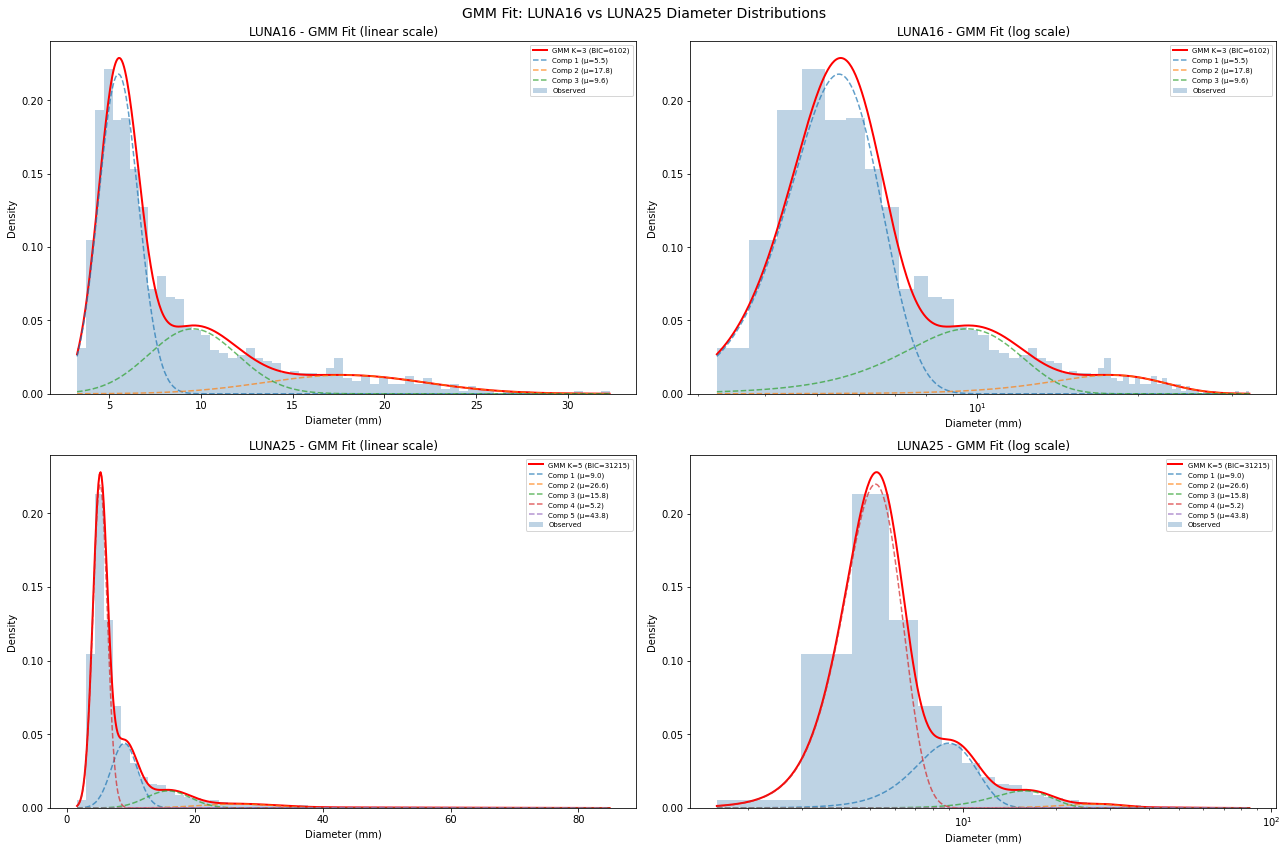

In [6]:
from sklearn.mixture import GaussianMixture
import numpy as np

import matplotlib.pyplot as plt

datasets = {
    "LUNA16": diameters_16["diameter_mm"].dropna().values,
    "LUNA25": diameters_25["nlst_diameter_mm"].dropna().values,
}

gmm_fits = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_idx, (name, data) in enumerate(datasets.items()):
    data_col = data.reshape(-1, 1)
    
    # Find best GMM by BIC
    gmm_results = []
    for k in range(1, 6):
        gmm = GaussianMixture(n_components=k, random_state=42, max_iter=500)
        gmm.fit(data_col)
        gmm_results.append((k, gmm, gmm.bic(data_col)))
    
    best_k, best_gmm, best_bic = min(gmm_results, key=lambda x: x[2])
    gmm_fits[name] = {"gmm": best_gmm, "k": best_k, "bic": best_bic}
    
    print(f"\n[{name}] Best GMM: K={best_k}, BIC={best_bic:.2f}")
    for i, (w, m, c) in enumerate(zip(best_gmm.weights_, best_gmm.means_, best_gmm.covariances_)):
        print(f"  Component {i+1}: weight={w:.3f}, mean={m[0]:.2f}, std={np.sqrt(c[0,0]):.2f}")

    x_plot = np.linspace(data.min(), data.max(), 500)
    x_plot_log = np.exp(np.linspace(np.log(max(data.min(), 1e-3)), np.log(data.max()), 500))

    for col_idx, (x_ax, scale) in enumerate(zip([x_plot, x_plot_log], ["linear", "log"])):
        ax = axes[row_idx, col_idx]
        ax.hist(data, bins=60, density=True, alpha=0.35, color="steelblue", label="Observed")
        
        gmm_pdf = np.exp(best_gmm.score_samples(x_ax.reshape(-1, 1)))
        ax.plot(x_ax, gmm_pdf, "r-", lw=2, label=f"GMM K={best_k} (BIC={best_bic:.0f})")
        
        # Plot individual components
        for i, (w, m, cov) in enumerate(zip(best_gmm.weights_, best_gmm.means_, best_gmm.covariances_)):
            comp_pdf = w * (1 / np.sqrt(2 * np.pi * cov[0, 0])) * np.exp(-0.5 * ((x_ax - m[0])**2) / cov[0, 0])
            ax.plot(x_ax, comp_pdf, "--", lw=1.5, alpha=0.7, label=f"Comp {i+1} (μ={m[0]:.1f})")
        
        if scale == "log":
            ax.set_xscale("log")
        ax.set_xlabel("Diameter (mm)")
        ax.set_ylabel("Density")
        ax.set_title(f"{name} - GMM Fit ({scale} scale)")
        ax.legend(fontsize=7)

plt.suptitle("GMM Fit: LUNA16 vs LUNA25 Diameter Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
X25 = datasets["LUNA25"].reshape(-1,1)

# Compute log densities 
log_luna16 = gmm_fits["LUNA16"]["gmm"].score_samples(X25)
log_luna25 = gmm_fits["LUNA25"]["gmm"].score_samples(X25)

# Density ratio in log space
log_w = log_luna16 - log_luna25
log_w = np.clip(log_w, -10, 10)
w = np.exp(log_w)

In [10]:
# normalize weights
w_norm = w / w.max()

# sample with probability proportional to weight (soft filtering)
# Cutting based on w_norm would implement rigid cutoff sensible to threshold

keep_prob = w / np.sum(w)
mask = np.random.choice(
    len(X25),
    size=int(len(X25) * 0.7),
    replace=False,
    p=keep_prob
)
X25_filtered = X25[mask]


X25_filtered = X25[mask]

In [11]:
print("Before:", X25.shape[0])
print("After :", X25_filtered.shape[0])

Before: 5917
After : 4141


In [12]:
import numpy as np
from scipy import stats

filtered_diams = X25_filtered.ravel()

skewness = stats.skew(filtered_diams)
kurt = stats.kurtosis(filtered_diams)
mean = filtered_diams.mean()
std = filtered_diams.std()
median = np.median(filtered_diams)

print("=== LUNA25 Filtered Diameter Statistics ===")
print(f"  N         : {len(filtered_diams)}")
print(f"  Mean      : {mean:.4f} mm")
print(f"  Std       : {std:.4f} mm")
print(f"  Median    : {median:.4f} mm")
print(f"  Skewness  : {skewness:.4f}  ({'right-skewed' if skewness > 0 else 'left-skewed'})")
print(f"  Kurtosis  : {kurt:.4f}  ({'leptokurtic' if kurt > 0 else 'platykurtic'})")

stat_sw, p_sw = stats.shapiro(filtered_diams[:5000])
stat_ks, p_ks = stats.kstest(filtered_diams, "norm", args=(mean, std))
print(f"  Shapiro-Wilk  : stat={stat_sw:.4f}, p={p_sw:.4e} -> {'NOT normal' if p_sw < 0.05 else 'normal'}")
print(f"  KS vs Normal  : stat={stat_ks:.4f}, p={p_ks:.4e} -> {'NOT normal' if p_ks < 0.05 else 'normal'}")

# Compare with original LUNA25 and LUNA16
print("\n=== Comparison ===")
for name, data in [("LUNA16", luna16_diams), ("LUNA25 Original", luna25_diams), ("LUNA25 Filtered", filtered_diams)]:
    print(f"  {name:20s}: mean={data.mean():.2f}, std={data.std():.2f}, median={np.median(data):.2f}, skew={stats.skew(data):.2f}, kurt={stats.kurtosis(data):.2f}")

# KS tests
ks_stat_f16, ks_p_f16 = stats.ks_2samp(luna16_diams, filtered_diams)
ks_stat_f25, ks_p_f25 = stats.ks_2samp(luna25_diams, filtered_diams)
print(f"\nKS test (LUNA16 vs LUNA25 Filtered)  : stat={ks_stat_f16:.4f}, p={ks_p_f16:.4e}")
print(f"KS test (LUNA25 vs LUNA25 Filtered)  : stat={ks_stat_f25:.4f}, p={ks_p_f25:.4e}")

=== LUNA25 Filtered Diameter Statistics ===
  N         : 4141
  Mean      : 7.9430 mm
  Std       : 4.6530 mm
  Median    : 6.2320 mm
  Skewness  : 1.8610  (right-skewed)
  Kurtosis  : 3.3043  (leptokurtic)
  Shapiro-Wilk  : stat=0.7837, p=0.0000e+00 -> NOT normal
  KS vs Normal  : stat=0.1930, p=1.5562e-135 -> NOT normal

=== Comparison ===
  LUNA16              : mean=8.31, std=4.76, median=6.43, skew=1.75, kurt=2.83
  LUNA25 Original     : mean=8.45, std=6.88, median=6.09, skew=3.55, kurt=18.39
  LUNA25 Filtered     : mean=7.94, std=4.65, median=6.23, skew=1.86, kurt=3.30

KS test (LUNA16 vs LUNA25 Filtered)  : stat=0.0483, p=2.5909e-02
KS test (LUNA25 vs LUNA25 Filtered)  : stat=0.0364, p=3.0067e-03


## First annotation only
The following section attempts to consider only the lesions that are seen for the first time.
LUNA25 dataset tracks lesions over time, hence there could be lots of lesions that have evolved during screeing followups toward bigger nodules.

In [ ]:
# Load the annotations file to get StudyDate
annotations = pd.read_csv("luna25-annotations.csv")
lesion_stats = pd.read_csv("lesion_stats.csv")

lookup = annotations.set_index("AnnotationID")['StudyDate']

lesion_stats['StudyDate'] = lesion_stats['AnnotationID'].map(lookup)

In [53]:
# Keep only the first annotation for each LesionID (the oldest StudyDate)
lesion_stats_first = (
    lesion_stats
    .sort_values("StudyDate")
    .groupby(["PatientID", "NoduleID"], as_index=False)
    .first()
)

print(f"Original rows: {len(lesion_stats)}")
print(f"Rows after keeping first annotation per LesionID: {len(lesion_stats_first)}")
display(lesion_stats_first[["PatientID", "LesionID", "AnnotationID", "StudyDate", "nodule_volume_mm3", "label"]].head(10))

Original rows: 5917
Rows after keeping first annotation per LesionID: 3639


,PatientID,LesionID,AnnotationID,StudyDate,nodule_volume_mm3,label
0,100012,1,100012_1_19990102,19990102,521.850586,1
1,100035,1,100035_1_19990102,19990102,44.632032,0
2,100069,1,100069_1_20000102,20000102,217.048823,0
3,100069,2,100069_2_20000102,20000102,206.424055,0
4,100069,3,100069_3_20000102,20000102,141.916538,0
5,100095,1,100095_1_19990102,19990102,64.762215,0
6,100095,2,100095_2_19990102,19990102,307.842308,0
7,100095,3,100095_3_19990102,19990102,188.076569,0
8,100095,5,100095_5_19990102,19990102,221.788406,0
9,100150,1,100150_1_20000102,20000102,39.062500,0


First observations: 3639
Subsequent observations: 2278


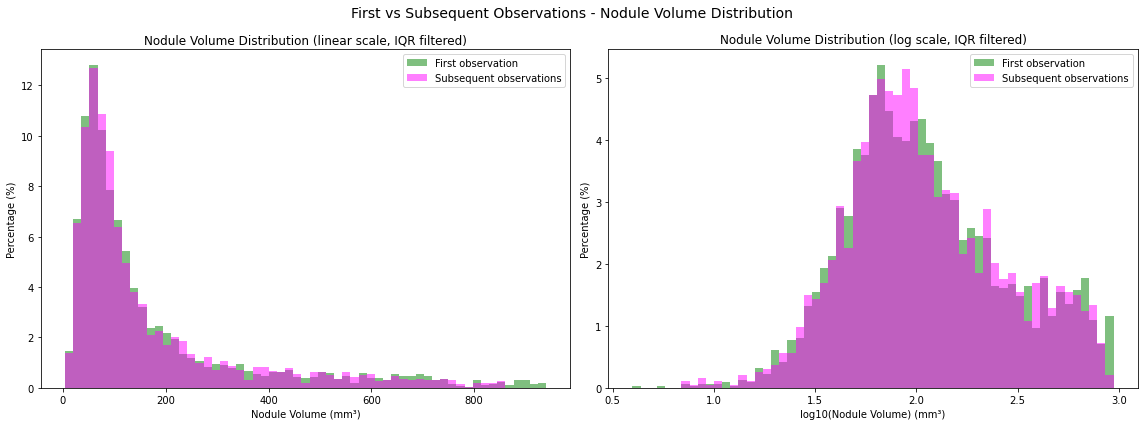


=== First observation ===


count    3094.000000
mean      175.335924
std       188.715845
min         3.959198
25%        59.315876
50%        99.270747
75%       203.018518
max       939.989329
Name: nodule_volume_mm3, dtype: float64


=== Subsequent observations ===


count    1944.000000
mean      168.789380
std       174.448653
min         6.929636
25%        60.376098
50%        96.516783
75%       202.835387
max       860.351562
Name: nodule_volume_mm3, dtype: float64

In [58]:
# Get subsequent observations (all except the first)
lesion_stats_subsequent = lesion_stats[~lesion_stats.index.isin(lesion_stats_first.index)]

print(f"First observations: {len(lesion_stats_first)}")
print(f"Subsequent observations: {len(lesion_stats_subsequent)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series >= Q1 - 1.5 * IQR) & (series <= Q3 + 1.5 * IQR)

groups = {
    "First observation": lesion_stats_first["nodule_volume_mm3"].dropna(),
    "Subsequent observations": lesion_stats_subsequent["nodule_volume_mm3"].dropna(),
}

colors = {"First observation": "green", "Subsequent observations": "magenta"}

# Remove outliers per group
clean_groups = {
    name: series[remove_outliers(series)]
    for name, series in groups.items()
}

# Shared bins
all_vals = np.concatenate([s.values for s in clean_groups.values()])
linear_bins = np.linspace(all_vals.min(), all_vals.max(), 60)
log_bins = np.linspace(np.log10(np.clip(all_vals, 1e-3, None)).min(),
                       np.log10(np.clip(all_vals, 1e-3, None)).max(), 60)

for col_idx, (scale, bins) in enumerate(zip(["linear", "log"], [linear_bins, log_bins])):
    ax = axes[col_idx]
    for name, series in clean_groups.items():
        data = series if scale == "linear" else np.log10(series.clip(lower=1e-3))
        weights = np.ones(len(data)) / len(data) * 100
        ax.hist(data, bins=bins, alpha=0.5, color=colors[name], label=name, weights=weights)
    ax.set_xlabel("Nodule Volume (mm³)" if scale == "linear" else "log10(Nodule Volume) (mm³)")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"Nodule Volume Distribution ({scale} scale, IQR filtered)")
    ax.legend()

plt.suptitle("First vs Subsequent Observations - Nodule Volume Distribution", fontsize=14)
plt.tight_layout()
plt.show()

for name, series in clean_groups.items():
    print(f"\n=== {name} ===")
    display(series.describe())
